# Ejercicio 1: Funciones base de Bernstein
Punto C: 

Demostración Algebraica de la Partición de la Unidad

Primero desglosamos y expandimos cada uno de los polinomios:

$$b_{0}(t) = (1-t)^3 = 1 - 3t + 3t^2 - t^3$$
$$b_{1}(t) = 3(1-t)^2t = 3(1 - 2t + t^2)t = 3t - 6t^2 + 3t^3$$
$$b_{2}(t) = 3(1-t)t^2 = 3t^2 - 3t^3$$
$$b_{3}(t) = t^3$$

Después sumamos las cuatro expresiones miembro a miembro:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = (1 - 3t + 3t^2 - t^3) + (3t - 6t^2 + 3t^3) + (3t^2 - 3t^3) + (t^3)$$

Agrupamos los términos según la potencia de $t$:

* **Término independiente:** $1$
* **Términos con $t$:** $-3t + 3t = 0$
* **Términos con $t^2$:** $3t^2 - 6t^2 + 3t^2 = 0$
* **Términos con $t^3$:** $-t^3 + 3t^3 - 3t^3 + t^3 = 0$

Y listo: al cancelarse todos los términos dependientes de $t$, llegamos al resultado final:

$$b_{0}(t) + b_{1}(t) + b_{2}(t) + b_{3}(t) = 1, \quad \forall t \in [0, 1]$$

Punto D:

Esto valida la razón por la que consideramos que la curva es una combinación convexa de los puntos de control. Sabemos que las funciones son siempre mayores o iguales a cero en el intervalo $[0,1]$ y como vimos su suma da exactamente $1$. 

Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:
 
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [9.70002030e-01 2.96939397e-02 3.02999385e-04 1.03061015e-06]
 [9.40610059e-01 5.81820655e-02 1.19963022e-03 8.24488122e-06]
 [9.11817904e-01 8.54829285e-02 2.67134151e-03 2.78264741e-05]
 [8.83619379e-01 1.11615079e-01 4.69958229e-03 6.59590497e-05]
 [8.56008303e-01 1.36597070e-01 7.26580157e-03 1.28826269e-04]
 [8.28978490e-01 1.60447450e-01 1.03514484e-02 2.22611793e-04]
 [8.02523758e-01 1.83184771e-01 1.39379717e-02 3.53499282e-04]
 [7.76637923e-01 2.04827584e-01 1.80068206e-02 5.27672398e-04]
 [7.51314801e-01 2.25394440e-01 2.25394440e-02 7.51314801e-04]
 [7.26548208e-01 2.44903890e-01 2.75172911e-02 1.03061015e-03]
 [7.02331962e-01 2.63374486e-01 3.29218107e-02 1.37174211e-03]
 [6.78659877e-01 2.80824777e-01 3.87344520e-02 1.78089434e-03]
 [6.55525771e-01 2.97273315e-01 4.49366639e-02 2.26425050e-03]
 [6.32

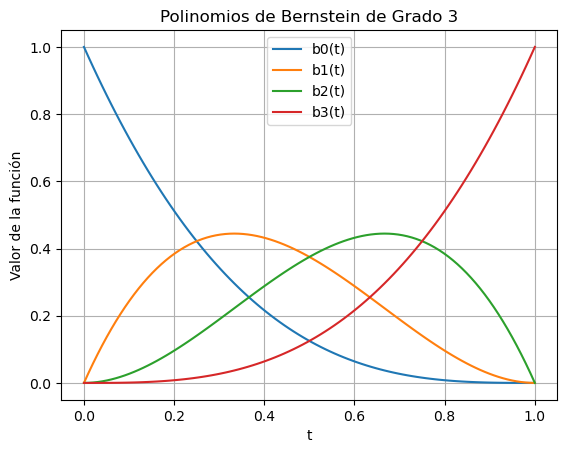

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def bernstein3(t: np.ndarray) -> np.ndarray:

    b0: np.ndarray = (1 - t)**3 
    b1: np.ndarray = 3 * (1 - t)**2 * t 
    b2: np.ndarray = 3 * (1 - t) * t**2 
    b3: np.ndarray = t**3 
    
    # matriz_base es un np.ndarray, pero cambia su forma a una bidimensional de tipo (m, 4)
    matriz_base: np.ndarray = np.column_stack((b0, b1, b2, b3))
    return matriz_base

#estos son mis 100 valores de t
t_real: np.ndarray = np.linspace(0, 1, 100) 
resultado: np.ndarray = bernstein3(t_real)

print("Le vamos a pasar 100 valores equispaciados de t a la función berstein3 del 0 al 1 y nos devuelve esta matriz:")
print(" ")
print(resultado)

print("Y ahora graficamos las 4 funciones en el intervalo [0,1]")
t = np.linspace(0, 1, 100)

matriz = bernstein3(t)

# grafico cada columna. En NumPy, matriz[:, 0] significa "toda la columna 0"
plt.plot(t, matriz[:, 0], label="b0(t)")  # grafica b0
plt.plot(t, matriz[:, 1], label="b1(t)")  # grafica b1
plt.plot(t, matriz[:, 2], label="b2(t)")  # grafica b2
plt.plot(t, matriz[:, 3], label="b3(t)")  # grafica b3 

plt.title("Polinomios de Bernstein de Grado 3")
plt.xlabel("t")
plt.ylabel("Valor de la función")
plt.legend()  # muestra el cartelito de qué color es cada función
plt.grid(True) 

plt.show()

# Ejercicio 2: Evaluación matricial de una curva de Bézier

Para tener en cuenta que aprendimos que en numpy np.vstack pega los arreglos uno arriba del otro (en forma de filas). Y np.column_stack pega los arreglos uno al lado del otro (en forma de columnas).

Punto D:    El producto C = AP da los puntos de la curva de Bezier

A es la matriz que tiene los valores de los 4 polinomios de Berstein evaluados en 100 valores equispaciado de t entre 0 y 1. Su dimensión es 100 filas x 4 columnas

P es la matriz de puntos de control. Cada una de las 4 filas tiene el valor de los puntos de control. En la primera columna están los valores de x y en la segunda los valores de y. 

C es la es la matriz de puntos de la curva de bezier porque multiplica cada fila de A (polinomios de berstein evaluados en 100 valores) por los valores de los puntos de control en X y en Y. Se obtiene en C una matriz con 2 columnas y 100 filas. 100 valores de X e Y para graficar la curva de Bezier.




Ahora construyo una matriz P de dimensión 4 x 2 cuyas filas sean los puntos de control:
[[0 0]
 [1 3]
 [4 3]
 [5 0]]

Ahora calculamos los puntos de la curva mediante el producto A x P = C

[[0.         0.        ]
 [0.03091109 0.08999082]
 [0.06302181 0.17814509]
 [0.09630743 0.26446281]
 [0.1307432  0.34894399]
 [0.16630441 0.43158861]
 [0.2029663  0.51239669]
 [0.24070415 0.59136823]
 [0.27949323 0.66850321]
 [0.31930879 0.74380165]
 [0.36012611 0.81726354]
 [0.40192044 0.88888889]
 [0.44466706 0.95867769]
 [0.48834122 1.02662994]
 [0.5329182  1.09274564]
 [0.57837326 1.15702479]
 [0.62468167 1.2194674 ]
 [0.67181869 1.28007346]
 [0.71975958 1.33884298]
 [0.76847961 1.39577594]
 [0.81795405 1.45087236]
 [0.86815817 1.50413223]
 [0.91906722 1.55555556]
 [0.97065647 1.60514233]
 [1.02290119 1.65289256]
 [1.07577664 1.69880624]
 [1.12925809 1.74288338]
 [1.18332081 1.78512397]
 [1.23794006 1.82552801]
 [1.2930911  1.8640955 ]
 [1.3487492  1.90082645]
 [1.40488963 1.93572084]
 [1.461487

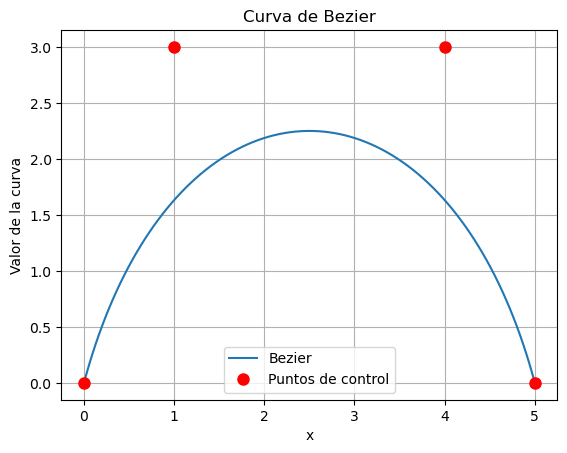

In [2]:

print("Ahora construyo una matriz P de dimensión 4 x 2 cuyas filas sean los puntos de control:")

def crear_matriz_puntos_control(p0, p1, p2, p3) -> np.ndarray:
   
    # apilar como filas para obtener una matriz de forma (4, 2)
    matriz_de_puntos_control: np.ndarray = np.vstack((p0, p1, p2, p3))
    return matriz_de_puntos_control

P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))
print(P)

print("")
print("Ahora calculamos los puntos de la curva mediante el producto A x P = C")
print("")


A = bernstein3(t_real)

def puntos_de_la_curva(A: np.ndarray, P: np.ndarray):
    C: np.ndarray = A @ P
    return C

C: np.ndarray = puntos_de_la_curva(A, P)
print(C)

plt.plot(C[:, 0], C[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()





# Ejercicio 3: Generación de datos con ruido



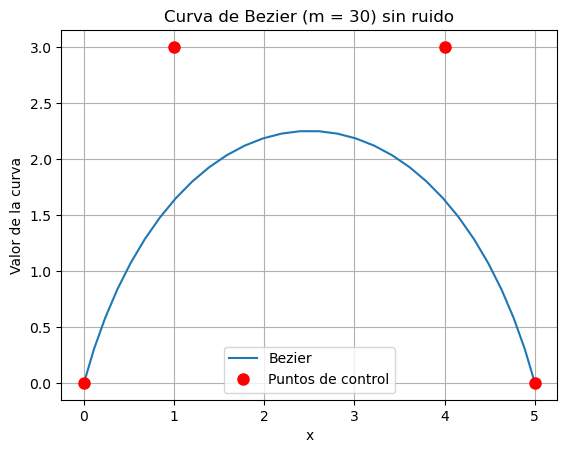

Ahora creamos la curva con ruido



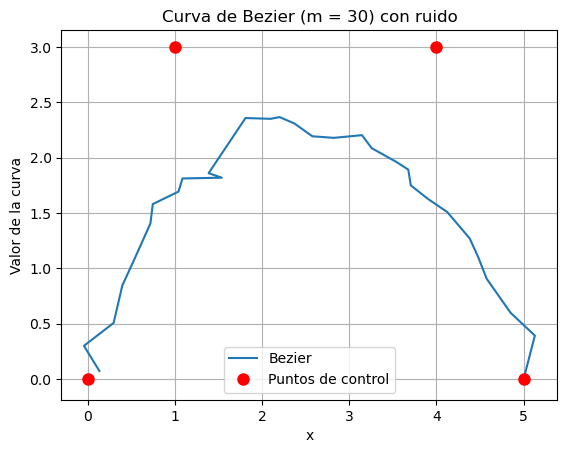

In [3]:
import numpy as np
import matplotlib.pyplot as plt

t_real: np.ndarray = np.linspace(0, 1, 30) 
A: np.ndarray = bernstein3(t_real)

P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))#función del 2)
C: np.ndarray = puntos_de_la_curva(A, P)# matriz C, B(t)

plt.plot(C[:, 0], C[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier (m = 30) sin ruido")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()


#3) c) y d)
print("Ahora creamos la curva con ruido")
print("")
np.random.seed(10)

# loc=0.0 (media cero)
# scale=0.1 (desviación estándar, o sea, qué tan "fuerte" es el ruido)
# size=(30, 2) (porque querés un valor de ruido para cada X y cada Y de los 30 puntos)
ruido: np.ndarray = np.random.normal(loc=0.0, scale=0.1, size=(30, 2))

datos_ruidosos: np.ndarray = C + ruido#hace la suma fila por fila en las 2 columnas x e y -> tenemos la curva Q(t)

plt.plot(datos_ruidosos[:, 0], datos_ruidosos[:, 1], label= "Bezier")  
plt.plot(P[:, 0], P[:, 1], "ro", markersize=8, label="Puntos de control")

plt.title("Curva de Bezier (m = 30) con ruido")
plt.xlabel("x")
plt.ylabel("Valor de la curva")
plt.legend()  # el color
plt.grid(True) 

plt.show()




# Ejercicio 4: Ajuste de una curva de Bézier por mínimos cuadrados

AP son los puntos de la curva de Bezier a graficar, siendo A la matriz de las funciones de Berstein evaluadas en m=30 valores equispaciados entre 0 y 1 y P los puntos de control (dimensión 4*2). Pero en el ejercicio anterior generamos puntos con ruido gaussiano. Esos puntos ruidosos son Q= AP + ruido. Como hay ruido, Q no está exactamente sobre ninguna curva de Bézier. Queremos encontrar la P̂ tal que AP̂ sea la curva que mejor se aproxima a esos puntos ruidosos. Es decir que AP̂ sea lo mas parecida a Q. Eso es exactamente mínimos cuadrados. 

Investigamos y descubrimos que ‖AP - Q‖² es simplemente la raíz cuadrada de la suma de todos los elementos al cuadrado. $$\|AP - Q\|_F^2 = \sum_{i,j} (AP - Q)_{ij}^2$$

**Por qué esto se reduce a mínimos cuadrados**

Vimos que Q tiene 2 columnas, y P también tiene 2 columnas. Si llamamos q₁, q₂ a las columnas de Q, y p₁, p₂ a las de P:

$$\|AP - Q\|_F^2 = \|Ap_1 - q_1\|^2 + \|Ap_2 - q_2\|^2$$

O sea, el problema se separa en dos problemas de mínimos cuadrados independientes, uno por cada columna. Cada uno tiene la forma clásica que ya conocemos: minimizar ‖Ax - b‖².
La solución de cada uno es la ecuación normal:

$$A^T A \hat{p}_i = A^T q_i$$

Y como ambos comparten la misma A, lo resolvimos juntos como un solo sistema matricial:

$$A^T A \hat{P} = A^T Q$$

Comparación entre los puntos de control originales y los puntos de control estimados (punto e): No son exactamente iguales porque la curva que tiene esos puntos intentará acercarse lo mas posible a los puntos observados con ruido no a los puntos de la curva de bezier original. Si ese hubiese sido el caso al hacer cuadrados mínimos habríamos obtenido la matriz P con los puntos de control originales. Es decir, solo si el ruido fuera cero (σ = 0), recuperaríamos exactamente los puntos de control originales. 

Qué ocurre cuando aumenta el nivel de ruido (punto i): A medida que aumenta el nivel de ruido la curva ajustada pierde su forma original. Sus puntos de control estimados son cada vez mas diferentes a los de la curva original. 

Sabemos que la curva de Bézier en cada punto t es un promedio ponderado de los 4 puntos de control (eso es lo que hacen los polinomios de Bernstein). Entonces cuando mínimos cuadrados ajusta la curva a 30 puntos ruidosos, el ruido de esos 30 puntos se promedia a lo largo de toda la curva. Porque si el ruido es gaussiano con media cero, esa suma tiende a cancelarse, unos positivos, otros negativos. Eso es el promedio.
Pero los 4 puntos de control tienen que cargar solos con todo el ajuste. Para que AP̂ se acerque a Q punto a punto, P̂ se tiene que mover bastante respecto a P. Cuanto mayor es σ, más dispersos están los 30 puntos ruidosos, y más tienen que moverse los puntos de control para compensar aunque la curva final igual se vea razonable porque los errores se siguen promediando.


Acá está el P sombrero que minimiza la expresión ||AP - Q||**2:

[[ 0.05064689 -0.06943931]
 [ 0.89111267  3.17213596]
 [ 4.08059359  2.83194426]
 [ 5.0192952  -0.03759889]]

Y acá lo resolvimos usando la forma de la ecuación normal: (nos dio lo mismo)

[[ 0.05064689 -0.06943931]
 [ 0.89111267  3.17213596]
 [ 4.08059359  2.83194426]
 [ 5.0192952  -0.03759889]]


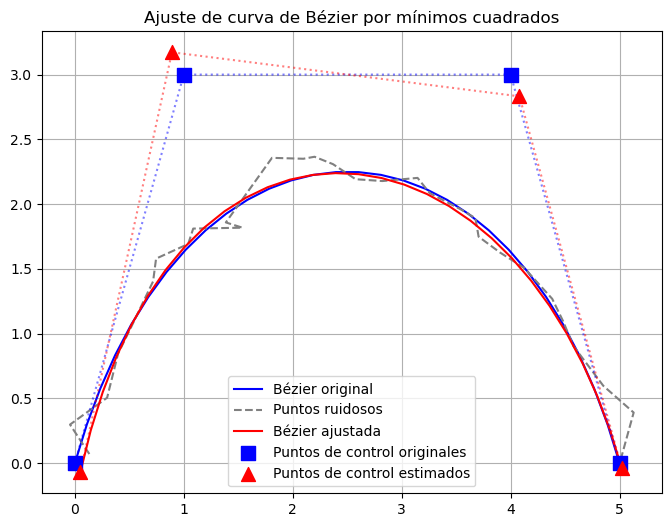

Repetimos el procedimiento anterior para distintos niveles de ruido.


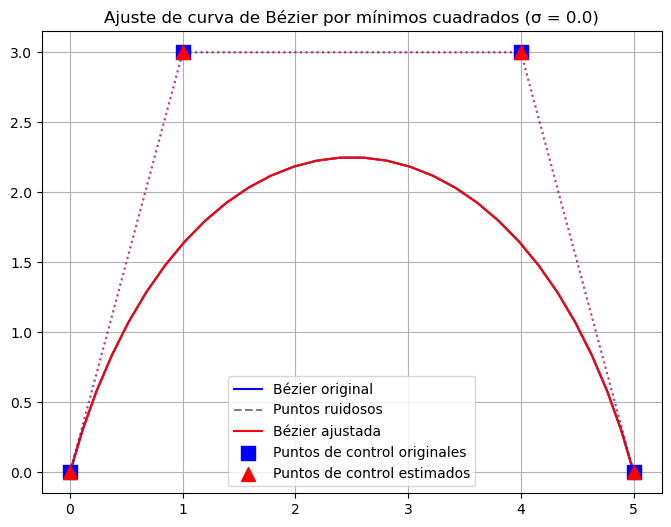

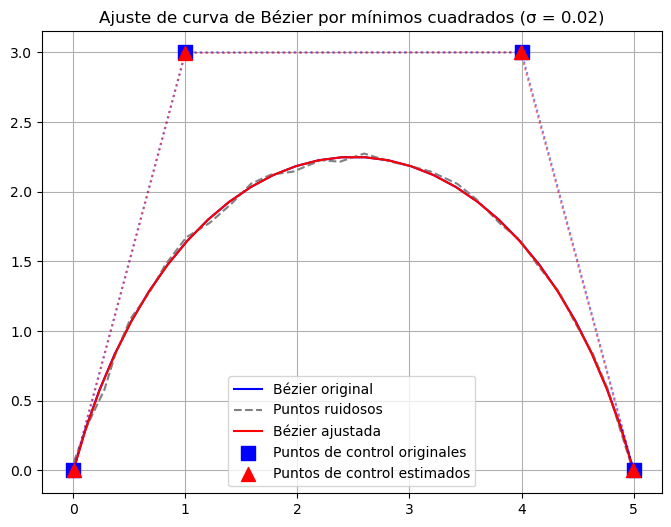

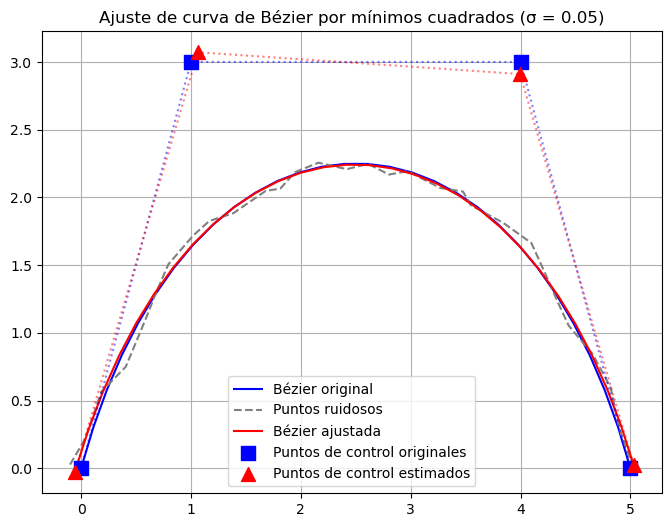

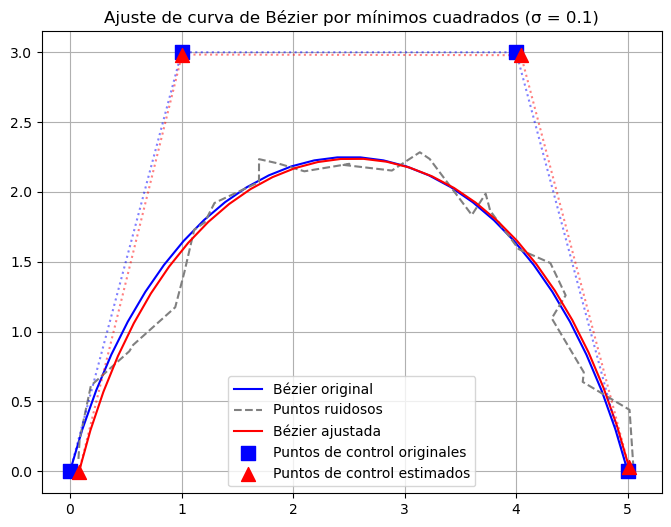

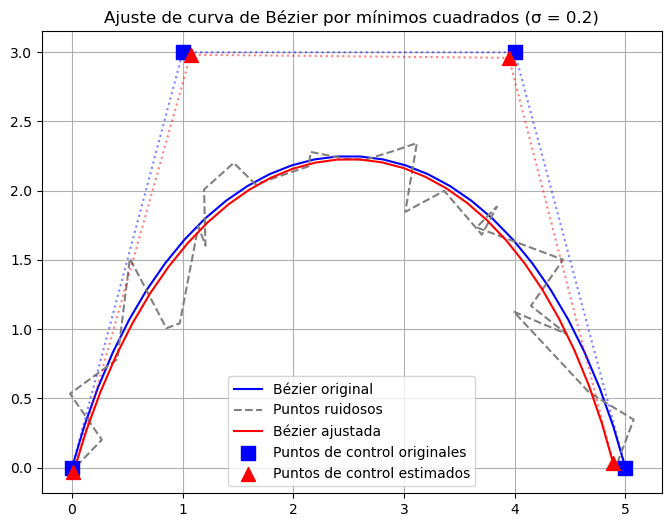

sigma=0.0  ECM=0.000000
sigma=0.02  ECM=0.000019
sigma=0.05  ECM=0.000697
sigma=0.1  ECM=0.001651
sigma=0.2  ECM=0.003044


In [4]:
import numpy as np
import matplotlib.pyplot as plt

#a)
t_real: np.ndarray = np.linspace(0, 1, 30)
A: np.ndarray = bernstein3(t_real)

#b)
ruido: np.ndarray = np.random.normal(loc=0.0, scale=0.1, size=(30, 2))
P = crear_matriz_puntos_control((0, 0), (1, 3), (4, 3), (5, 0))

Q: np.ndarray = A @ P + ruido

# A es tu matriz de m x 4, Q es nuestra matriz de m x 2
# lstsq resuelve mínimos cuadrados columna a columna y devuelve la P̂ de 4×2 directamente.
P_sombrero: np.ndarray = np.linalg.lstsq(A, Q, rcond=None)[0]

print ("Acá está el P sombrero que minimiza la expresión ||AP - Q||**2:")
print ("")
print (P_sombrero)
print ("")
print ("Y acá lo resolvimos usando la forma de la ecuación normal: (nos dio lo mismo)")
print ("")
#c)
P_sombrero_ecuación_normal = np.linalg.inv(A.T @ A) @ A.T @ Q
print (P_sombrero_ecuación_normal)
fig, ax = plt.subplots(figsize=(8, 6))

# Curvas
ax.plot(C[:, 0], C[:, 1], color='blue', label='Bézier original')
ax.plot(datos_ruidosos[:, 0], datos_ruidosos[:, 1], color='gray', linestyle='--', label='Puntos ruidosos')
ax.plot((A @ P_sombrero)[:, 0], (A @ P_sombrero)[:, 1], color='red', label='Bézier ajustada')

# Puntos de control originales
ax.scatter(P[:, 0], P[:, 1], color='blue', marker='s', s=100, zorder=5, label='Puntos de control originales')
ax.plot(P[:, 0], P[:, 1], color='blue', linestyle=':', alpha=0.5)

# Puntos de control estimados
ax.scatter(P_sombrero[:, 0], P_sombrero[:, 1], color='red', marker='^', s=100, zorder=5, label='Puntos de control estimados')
ax.plot(P_sombrero[:, 0], P_sombrero[:, 1], color='red', linestyle=':', alpha=0.5)

ax.legend()
ax.set_title('Ajuste de curva de Bézier por mínimos cuadrados')
ax.grid(True)
plt.show()
 

##############
#f)
print("Repetimos el procedimiento anterior para distintos niveles de ruido.")

sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]
ecms = []
for sigma in sigmas:  #repite todo el código hecho arriba pero en un ciclo
    fig, ax = plt.subplots(figsize=(8, 6))
    ruido_punto_f: np.ndarray = np.random.normal(loc=0.0, scale=sigma, size=(30, 2))
    Q_punto_f: np.ndarray = A @ P + ruido_punto_f
    
    #Resuelvo m[inimos cuadrados para esa Q con ruido 
    P_sombrero_punto_f: np.ndarray = np.linalg.lstsq(A, Q_punto_f, rcond=None)[0]
    ecms:list
    ecm = (1/30) * np.sum(np.linalg.norm(C - A @ P_sombrero_punto_f, axis=1)**2)
    ecms.append(ecm)
    # Curvas
    ax.plot(C[:, 0], C[:, 1], color='blue', label='Bézier original')
    ax.plot(Q_punto_f[:, 0], Q_punto_f[:, 1], color='gray', linestyle='--', label='Puntos ruidosos')
    ax.plot((A @ P_sombrero_punto_f)[:, 0], (A @ P_sombrero_punto_f)[:, 1], color='red', label='Bézier ajustada')

    # Puntos de control originales
    ax.scatter(P[:, 0], P[:, 1], color='blue', marker='s', s=100, zorder=5, label='Puntos de control originales')
    ax.plot(P[:, 0], P[:, 1], color='blue', linestyle=':', alpha=0.5)

    # Puntos de control estimados
    ax.scatter(P_sombrero_punto_f[:, 0], P_sombrero_punto_f[:, 1], color='red', marker='^', s=100, zorder=5, label='Puntos de control estimados')
    ax.plot(P_sombrero_punto_f[:, 0], P_sombrero_punto_f[:, 1], color='red', linestyle=':', alpha=0.5)

    ax.legend()
    ax.set_title(f'Ajuste de curva de Bézier por mínimos cuadrados (σ = {sigma})')
    ax.grid(True)
    plt.show()
    
#h)
for sigma, ecm in zip(sigmas, ecms):
    print(f"sigma={sigma}  ECM={ecm:.6f}")

# Ejercicio 5: La función de error como forma cuadrática

¿Qué sugiere el hecho de que todos los autovalores de $A^TA$ sobre la forma de la función de error?

Lo que sugieren los autovalores positivos es que la parte cuadrática $p^\top A^\top A p$ es definida positiva, lo que garantiza que E(p) tiene forma de "cuenco". Ahí hay un único mínimo global, sin mínimos locales ni direcciones planas.

Lo pensamos en 1D primero. Una función de la forma:

$$f(x) = ax^2 - bx + c$$

con $a > 0$ siempre tiene forma de parábola con mínimo único, sin importar cuánto valen $b$ y $c$. El $b$ inclina la parábola, el $c$ la sube o baja, pero la **curvatura** (que determina que sea un cuenco) la da solo el $a$.

Después vimos que en múltiples dimensiones es lo mismo. $E(p)$ tiene la forma:

$$E(p) = \underbrace{p^\top A^\top A p  } _ {\text{curvatura}} \underbrace{ - 2q^\top Ap}_{\text{inclinación}} + \underbrace{q^\top q}_{\text{constante}}$$

(expansión algebraica pedida en el inciso a)

El término cuadrático $p^\top A^\top A p$ con autovalores positivos garantiza que la función curva hacia arriba en todas las direcciones. El término lineal $-2q^\top Ap$ solo desplaza el punto donde está el mínimo, pero no puede crear un segundo mínimo ni aplanar la función. La constante $q^\top q$ solo sube o baja toda la función.





In [5]:
import numpy as np
import matplotlib.pyplot as plt

print (np.allclose(A.T @ A, (A.T @ A).T))
print ("$A^T$A es simétrica")

eigenvalues, eigenvectors = np.linalg.eig(A.T @ A)

#hacer un if, si es no simetrica es false
print(eigenvalues)

True
$A^T$A es simétrica
[7.51154315 4.8161144  1.70568592 0.25824389]


# Ejercicio 6: Ecuaciones normales a partir del gradiente

Veamos como imponer $\nabla E(p) = 0$ conduce a las ecuaciones normales: $A^T Ap = A^T q$. (Punto e)

$$\nabla E(p) = 2A^T(Ap - q)$$

El mínimo de una función se encuentra donde la derivada es cero:

$$2A^T(Ap - q) = 0$$

Dividimos por 2 y distribuimos:

$$A^T Ap - A^T q = 0$$

$$A^T Ap = A^T q$$

Ahí aparecen las ecuaciones normales.

Observaciones sobre la verificación de que el gradiente en p sombrero (de minimos cuadrados) es aproximadamente cero:

Si el gradiente de la función de error da cero en un vector P determinado, es porque en ese vector se alcanza un punto crítico. Como ya sabemos (por los autovalores positivos de A^TA) que E(p) es una forma cuadrática convexa con un único mínimo global, ese punto crítico tiene que ser justamente ese mínimo. Cuando vimos que el p sombrero que conseguimos por mínimos cuadrados evaluado en el gradiente de la función de error da casi cero, eso significa que el p sombrero es aproximadamente un punto crítico. Es decir, está muy cerca de ser el mínimo global.


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def gradiente(p, A, q) -> np.ndarray:
    p = np.asarray(p)
    # grad E(p) = 2 * A^T (A p - q)
    res = 2 * (A.T @ (A @ p - q))
    return res

print("Evaluamos el gradiente en un vector inicial cualquiera, por ejemplo p = (0, 0, 0, 0)")
print("")
print (gradiente ([0,0,0,0], A, Q[:, 0]))
print("")
print("Y ahora evaluamos el gradiente en la solución de mínimos cuadrados P sombrero (le pasamos los x de P)")
print("")
print(gradiente (P_sombrero_ecuación_normal[:, 0], A, Q[:, 0]))
print("")
print("Veamos si el gradiente en la solucion de MC es aproximadamente cero")
print("")

if (np.allclose(gradiente(P_sombrero_ecuación_normal[:, 0], A, Q[:, 0]), 0)):
    print (True)
else :
    print (False)




Evaluamos el gradiente en un vector inicial cualquiera, por ejemplo p = (0, 0, 0, 0)

[-12.98996725 -28.17151455 -44.40058241 -65.11347262]

Y ahora evaluamos el gradiente en la solución de mínimos cuadrados P sombrero (le pasamos los x de P)

[-3.11090129e-15  1.06338549e-15 -3.37230244e-15 -1.97619698e-14]

Veamos si el gradiente en la solucion de MC es aproximadamente cero

True


# Ejercicio 7: Gradiente descendiente para ajustar una curva

Implementamos gradiente descendente para minimizar $E(p) = \|Ap - q\|^2$.


Inicializo p0 de una manera aleatoria con un una media 4 y desviacion estandar 3

[0.47104495 4.07636742 1.54603574 7.15237387]
Implementamos la actualización pt+1 y la ejecutamos 100 veces

Iteración:  0 - Mínimo alcanzado hasta el momento:  26.4236350622204
Iteración:  1 - Mínimo alcanzado hasta el momento:  25.80525947487814
Iteración:  2 - Mínimo alcanzado hasta el momento:  25.20498035872339
Iteración:  3 - Mínimo alcanzado hasta el momento:  24.622259624047047
Iteración:  4 - Mínimo alcanzado hasta el momento:  24.056575217358613
Iteración:  5 - Mínimo alcanzado hasta el momento:  23.507420643247826
Iteración:  6 - Mínimo alcanzado hasta el momento:  22.974304500501432
Iteración:  7 - Mínimo alcanzado hasta el momento:  22.456750032055538
Iteración:  8 - Mínimo alcanzado hasta el momento:  21.954294688366133
Iteración:  9 - Mínimo alcanzado hasta el momento:  21.466489703800278
Iteración:  10 - Mínimo alcanzado hasta el momento:  20.992899685659324
Iteración:  11 - Mínimo alcanza

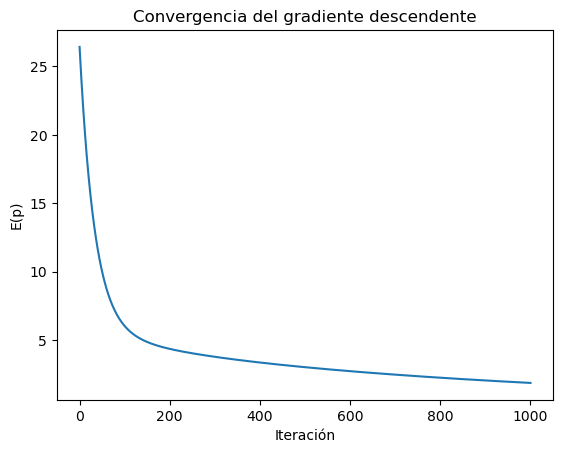

Ahora comparo el resultado final con la solución obtenida por ecuaciones normales y grafico

Pero antes calculo el metodo de gradiente descendiente para los Y de P0
Iteración:  0 - Mínimo alcanzado hasta el momento:  159.0872798005112
Iteración:  1 - Mínimo alcanzado hasta el momento:  155.61162390006746
Iteración:  2 - Mínimo alcanzado hasta el momento:  152.23080463600502
Iteración:  3 - Mínimo alcanzado hasta el momento:  148.94206166107097
Iteración:  4 - Mínimo alcanzado hasta el momento:  145.7427163301327
Iteración:  5 - Mínimo alcanzado hasta el momento:  142.63016927086196
Iteración:  6 - Mínimo alcanzado hasta el momento:  139.60189802675893
Iteración:  7 - Mínimo alcanzado hasta el momento:  136.65545477035982
Iteración:  8 - Mínimo alcanzado hasta el momento:  133.78846408453768
Iteración:  9 - Mínimo alcanzado hasta el momento:  130.99862080986668
Iteración:  10 - Mínimo alcanzado hasta el momento:  128.28368795608233
Iteración:  11 - Mínimo alcanzado hasta el momento:  12

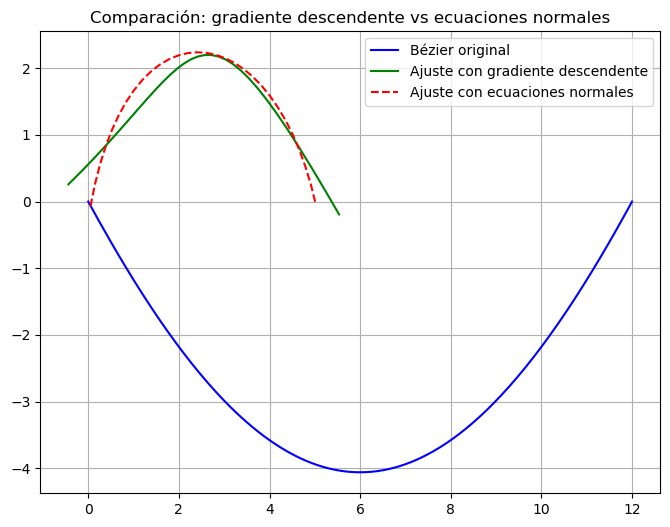

In [36]:
import numpy as np
import matplotlib.pyplot as plt


#a)
print("Inicializo p0 de una manera aleatoria con un una media 4 y desviacion estandar 3")
print("")
p0_x = np.random.normal(loc=0.0, scale=3, size=4)#genera 4 puntos x donde empieza el alg
p0_y = np.random.normal(loc=0.0, scale=3, size=4)
print(p0_x)


print("Implementamos la actualización pt+1 y la ejecutamos 100 veces")
print("")

def E(p, q):  # la funcion de error
    res = p @ A.T @ A @ p - 2 * q.T @ A @ p + q @ q
    return res

def metodo_de_primer_orden(p0, A, q, alpha, max_iter, TOLERANCIA=0.0001):  # devuelve el p que minimiza a la función de error
    p_t = p0
    iter = 0
    iteraciones = []
    errores = []

    while iter <= max_iter:
        print("Iteración: ", iter, "- Mínimo alcanzado hasta el momento: ", E(p_t, q))
        iteraciones.append(iter)
        errores.append(E(p_t, q))

        p_tsig = p_t - alpha * gradiente(p_t, A, q)#formula, con la función ejercicio anterior

        if abs(E(p_tsig, q) - E(p_t, q)) < TOLERANCIA:#si llegamos a un mínimo menor que la tolerancia, paramos
            p_t = p_tsig
            break

        p_t = p_tsig
        iter = iter + 1

    p_min = p_t
    print("El mínimo local ocurre en p = ", p_min, " y f(x) vale: ", E(p_min, q))

    return p_min, iteraciones, errores

#######################################
#calculo lado x
resultado_x = metodo_de_primer_orden(p0_x, A, Q[:, 0], 0.001, 1000)#Q es la primer Q hecha en el ejercicio 4)
p_min_x = resultado_x[0]
iteraciones_x = resultado_x[1]
errores_x = resultado_x[2]
print(p_min_x)

print("Veamos si es parecido al mínimo encontrado por Mínimos cuadrados en x")
print("")
print("Este era el P_sombrero con la ecuación normal en x:", P_sombrero_ecuación_normal[:, 0])

plt.plot(iteraciones_x, errores_x)
plt.xlabel('Iteración')
plt.ylabel('E(p)')
plt.title('Convergencia del gradiente descendente')
plt.show()

print("Ahora comparo el resultado final con la solución obtenida por ecuaciones normales y grafico")
print("")
print("Pero antes calculo el metodo de gradiente descendiente para los Y de P0")


#########################
#CALCULO DEL LADO Y -> hay que acerlo para poder graficar la curva
p_min_y, iteraciones_y, errores_y = metodo_de_primer_orden(p0_y, A, Q[:, 1], 0.001, 1000)

fig, ax = plt.subplots(figsize=(8, 6))
print("Veamos si es parecido al mínimo encontrado por Mínimos cuadrados en y")

print("Este era el P_sombrero con la ecuación normal en y:", P_sombrero_ecuación_normal[:, 1])



########################################
#ploteo de curvas
# Curva original
ax.plot(C[:, 0], C[:, 1], color='blue', label='Bézier original')

# Curva con gradiente descendente
P_grad = np.column_stack([p_min_x, p_min_y])
ax.plot((A @ P_grad)[:, 0], (A @ P_grad)[:, 1], color='green', label='Ajuste con gradiente descendente')

# Curva con ecuaciones normales -> todas variables guardas del ejercicio anterior
ax.plot((A @ P_sombrero_ecuación_normal)[:, 0], (A @ P_sombrero_ecuación_normal)[:, 1], color='red', linestyle='--', label='Ajuste con ecuaciones normales')

ax.legend()
ax.set_title('Comparación: gradiente descendente vs ecuaciones normales')
ax.grid(True)
plt.show()

# Ejercicio 8: Efecto de la tasa de aprendizaje

Usar el algoritmo del ejercicio anterior para estudiar el efecto de la tasa de aprendizaje α.

Sobre el rol que cumple α en el método: Según lo que vimos el α representa el tamaño del paso que vas a dar para pasar al siguiente punto de la funcion que puede ser el mínimo. Por ejemplo, vimos que en el caso del α mas chico (caso α = 0,0001), le costó muchas iteraciones acercarse al cero, en cambio con el mas grande fue mas rapido. Eso no quiere decir que siempre un α mas grande (caso α = 0,1) sea mejor, solo que en este caso un α cercano a 0,1 por ejemplo, era suficiente para encontrar un número cerca de cero en poco tiempo.En otras palabras, si α es demasiado grande, el paso puede "pasarse" del mínimo en cada iteración, haciendo que el método oscile o incluso diverja en vez de converger.

Hubo casos donde el método diverjía.



C:\Users\Isaac\AppData\Local\Temp\ipykernel_8232\2577447729.py:17: RuntimeWarning: overflow encountered in matmul
  res = p @ A.T @ A @ p - 2 * q.T @ A @ p + q @ q
C:\Users\Isaac\AppData\Local\Temp\ipykernel_8232\2301524906.py:19: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(E(p_tsig, q) - E(p_t, q)) < TOLERANCIA:


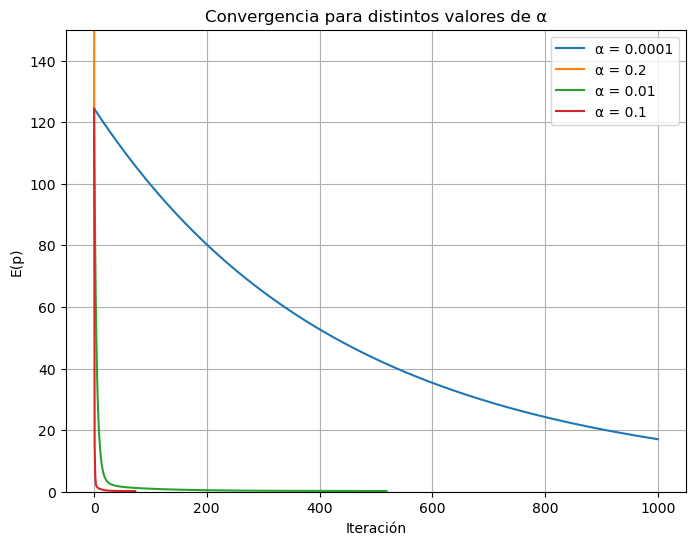

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# devuelve el p que minimiza a la función de error sin imprimir el proceso
#es la misma funcion de eantes pero sin printear las iteraciones
def metodo_de_primer_orden_directo(p0, A, q, alpha, max_iter, TOLERANCIA=0.0001):
    # Valor inicial de x
    p_t = p0
    iter = 0
    iteraciones = []
    errores = []

    while iter <= max_iter:
        iteraciones.append(iter)
        errores.append(E(p_t, q))

        p_tsig = p_t - alpha * gradiente(p_t, A, q)

        if abs(E(p_tsig, q) - E(p_t, q)) < TOLERANCIA:
            p_t = p_tsig
            break

        p_t = p_tsig
        iter = iter + 1

    p_min = p_t
    return p_min, iteraciones, errores


alphas = [10**-4, 0.2, 10**-2, 0.1]

fig, ax = plt.subplots(figsize=(8, 6))

for alpha in alphas:
    p_min, iteraciones_local, errores_local = metodo_de_primer_orden_directo(p0_x, A, Q[:, 0], alpha, 1000)
    ax.plot(iteraciones_local, errores_local, label=f'α = {alpha}')

ax.set_xlabel('Iteración')
ax.set_ylabel('E(p)')
ax.set_title('Convergencia para distintos valores de α')
ax.legend()
ax.grid(True)
plt.ylim(0, 150) # Ponemos como límite superior el error inicial que teníamos, asi la que diverge no nos come la escala
plt.show()

# Ejercicio 9:  Método de Newton para el mismo problema


c)
Debo esperar a Isaac para comparar

d)
El método de Newton optimiza una función construyendo localmente una aproximación cuadrática basada en su serie de Taylor de segundo orden y saltando analíticamente al mínimo de dicha aproximación. Sin embargo, nuestra función de error objetivo es:

$$E(p) = p^\top A^\top A p - 2q^\top A p + q^\top q$$

Dado que esta función es estrictamente cuadrática en toda su extensión, la "aproximación" de Taylor construida por la matriz Hessiana no es una estimación local, sino una representación global y matemáticamente idéntica a la función original. Por lo tanto, al calcular el vértice de este paraboloide, el método encuentra el mínimo global exacto de $E(p)$ en su primera y única iteración, volviendo redundantes los cálculos posteriores.


In [9]:
#9)a)
#historial de minimos que nos da el método de newton
historial_newton = []

def metodo_newton(p0, A, q, iteraciones=5):#fijo 5 para evitar ciclos
    # Le avisamos a la función que vamos a modificar la variable de afuera
    global historial_newton
    
    # Vaciamos por si se debe correr otra vez la función
    historial_newton.clear()
    
    #verificación de float para evitar errores
    p_t = np.array(p0, dtype=float)
    
    # Guardamos el punto inicial (usamos .copy() para que no se sobreescriba luego)
    historial_newton.append(p_t.copy())
    
    # Calculamos el Hessiano y su inversa 
    H = 2 * (A.T @ A)
    H_inv = np.linalg.inv(H)
    
    # Bucle iterativo
    for i in range(iteraciones):
        grad = gradiente(p_t, A, q)
        
        # Actualización de Newton
        p_t = p_t - H_inv @ grad
        
        # Agregamos el nuevo punto a la lista global
        historial_newton.append(p_t.copy())
        
    return p_t

#9)b)
p0_aleatorio = np.random.rand(4)
print("Mi vector p0 aleatorio es:")
print(p0_aleatorio)

print("El historial de mínimos es:")
p_final = metodo_newton(p0_aleatorio, A, Q[:, 0], iteraciones=5)#El llamado es solo con la primera columna de Q, los valores de "x"
print(historial_newton)
print("El mínimo encontrado al final entonces es:")
print(p_final)

print("Mi mínimo encontrado por mínimos cuadrados para la coordenada x era:", P_sombrero_ecuación_normal[:, 0])

Mi vector p0 aleatorio es:
[0.22875561 0.84149797 0.84435847 0.22014599]
El historial de mínimos es:
[array([0.22875561, 0.84149797, 0.84435847, 0.22014599]), array([0.05064689, 0.89111267, 4.08059359, 5.0192952 ]), array([0.05064689, 0.89111267, 4.08059359, 5.0192952 ]), array([0.05064689, 0.89111267, 4.08059359, 5.0192952 ]), array([0.05064689, 0.89111267, 4.08059359, 5.0192952 ]), array([0.05064689, 0.89111267, 4.08059359, 5.0192952 ])]
El mínimo encontrado al final entonces es:
[0.05064689 0.89111267 4.08059359 5.0192952 ]
Mi mínimo encontrado por mínimos cuadrados para la coordenada x era: [0.05064689 0.89111267 4.08059359 5.0192952 ]


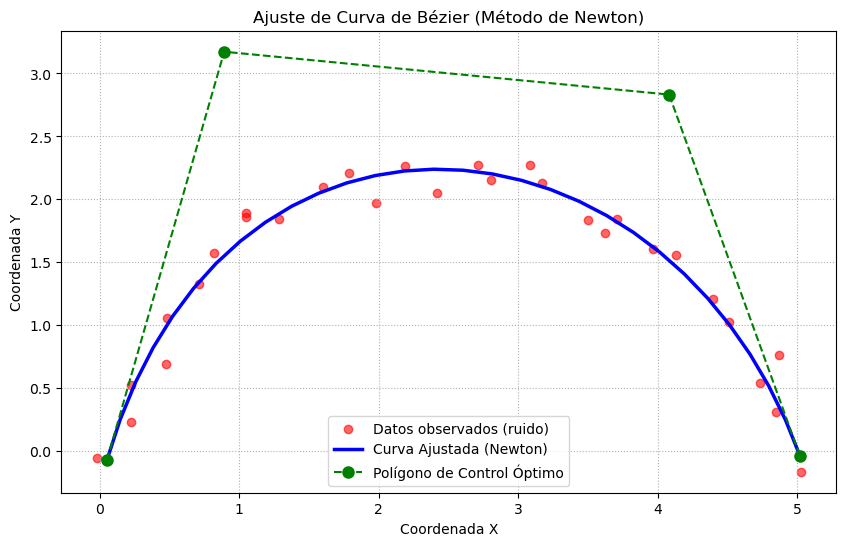

In [10]:
#9)e)
#Optimizamos las coordenadas X e Y por separado 
p_final_x = metodo_newton(p0_aleatorio, A, Q[:, 0], iteraciones=5)
p_final_y = metodo_newton(p0_aleatorio, A, Q[:, 1], iteraciones=5)

#Juntamos ambas columnas para formar la matriz P óptima de 4x2
P_optimo_newton = np.column_stack((p_final_x, p_final_y))

#Reconstruimos la curva teórica multiplicando A por los nuevos puntos de control
C_optima = A @ P_optimo_newton

#GRAFICOS
plt.figure(figsize=(10, 6))

# a) Los puntos ruidosos observados (Q)
plt.scatter(Q[:, 0], Q[:, 1], color='red', alpha=0.6, label='Datos observados (ruido)')

# b) La nueva curva ajustada por Newton
plt.plot(C_optima[:, 0], C_optima[:, 1], 'b-', linewidth=2.5, label='Curva Ajustada (Newton)')

# c) Los puntos de control y la poligonal de control óptima
plt.plot(P_optimo_newton[:, 0], P_optimo_newton[:, 1], 'go--', markersize=8, label='Polígono de Control Óptimo')

# Detalles estéticos
plt.title("Ajuste de Curva de Bézier (Método de Newton)")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.legend()
plt.grid(True, linestyle=':')

plt.show()

# Ejercicio 10: Ajuste con extremos fijos


A)

La ecuación de la curva de bezier que usamos para obtener los puntos de paso es:

$$B(t) = b_0(t)P_0 + b_1(t)P_1 + b_2(t)P_2 + b_3(t)P_3$$

b) 

Si queremos que nuestros puntos de paso de la Bezier sean como los de la Q, debemos tener algo como esto

$$b_0(t_i)P_0 + b_1(t_i)P_1 + b_2(t_i)P_2 + b_3(t_i)P_3 = q_i$$

Si despejamos lo que no conocemos, nos queda:

$$b_1(t_i)P_1 + b_2(t_i)P_2 = q_i - b_0(t_i)P_0 - b_3(t_i)P_3$$

Dimensión de la nueva matriz A_int: (30, 2)
Los puntos intermedios estimados (P1 y P2) son:
[[0.99430959 3.06449433]
 [4.0211699  3.00937258]]

La matriz de control final (P_sombrero con extremos fijos) es:
[[-0.02321823 -0.05017289]
 [ 0.99430959  3.06449433]
 [ 4.0211699   3.00937258]
 [ 5.02730493 -0.16185707]]


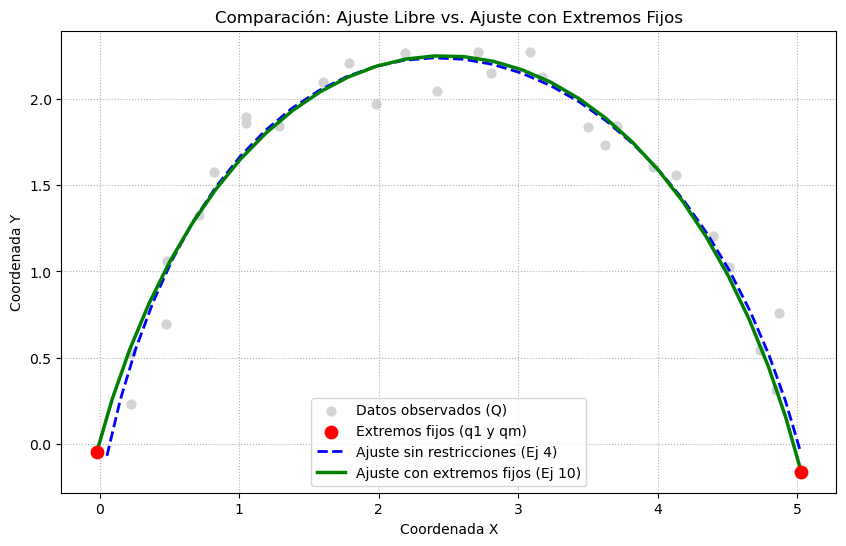

Se puede ver claramente en el gráfico como la versión ajustada coincide con los puntos inicial y final, mientras que la libre se dezplaza un poco de dichos puntos.


In [11]:
#10) c)


# En Python, A[:, 1:3] agarra todas las filas (:), y las columnas desde la 1 hasta la 2 (el 3 no se incluye)
A_int = A[:, 1:3]

print("Dimensión de la nueva matriz A_int:", A_int.shape)


#10) d)

#Fijamos los extremos según la consigna:
P0 = Q[0, :]   # El primer punto de Q
P3 = Q[-1, :]  # El último punto de Q (usar -1 en Python agarra el último elemento)

# Armamos los términos que vamos a pasar restando. 
# Le hacemos un .reshape(-1, 1) a las columnas de A para que Python entienda 
# que tiene que multiplicar la columna de 30 números por las 2 coordenadas (X,Y) del punto.
# o sea, se agarra solamente la parte de A que nos interesa, y la cortamos para que Python haga bien el producto
termino_0 = A[:, 0].reshape(-1, 1) * P0
termino_3 = A[:, 3].reshape(-1, 1) * P3

#Calculamos el "lado derecho" 
Q_modificado = Q - termino_0 - termino_3


#Resolvemos el problema de mínimos cuadrados para estimar SOLO P1 y P2
# (A_int tiene tamaño 30x2, y Q_modificado 30x2. El resultado será 2x2)
# los "_" son porque la función devuelve parámetros basura que no queremos usar
P_intermedios, _, _, _ = np.linalg.lstsq(A_int, Q_modificado, rcond=None)
print("Los puntos intermedios estimados (P1 y P2) son:")
print(P_intermedios)

#Juntamos P0, los intermedios, y P3 para armar la matriz final de 4x2
P_optimo_extremos_fijos = np.vstack((P0, P_intermedios, P3))

print("\nLa matriz de control final (P_sombrero con extremos fijos) es:")
print(P_optimo_extremos_fijos)



#e)
# Calculamos los puntos de ambas curvas multiplicando por A
C_libre = A @ P_optimo_newton
C_fija = A @ P_optimo_extremos_fijos

plt.figure(figsize=(10, 6))

#Graficamos los datos ruidosos observados
plt.scatter(Q[:, 0], Q[:, 1], color='lightgray', s=40, label='Datos observados (Q)')

#Resaltamos el primer y último punto de Q para que se vea que están "anclados"
plt.scatter([Q[0, 0], Q[-1, 0]], [Q[0, 1], Q[-1, 1]], color='red', s=80, zorder=5, label='Extremos fijos (q1 y qm)')

# Graficamos la curva libre 
plt.plot(C_libre[:, 0], C_libre[:, 1], 'b--', linewidth=2, label='Ajuste sin restricciones (Ej 4)')

#Graficamos la nueva curva con extremos fijos
plt.plot(C_fija[:, 0], C_fija[:, 1], 'g-', linewidth=2.5, label='Ajuste con extremos fijos (Ej 10)')

# Detalles estéticos
plt.title("Comparación: Ajuste Libre vs. Ajuste con Extremos Fijos")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.legend()
plt.grid(True, linestyle=':')

plt.show()

print("Se puede ver claramente en el gráfico como la versión ajustada coincide con los puntos inicial y final, mientras que la libre se dezplaza un poco de dichos puntos.")

# Ejercicio 11: Aplicación: una trayectoria para la podadora robot

Explicación sobre por qué una curva de grado muy bajo puede no tener suficiente flexibilidad para atravesar el jardín sin colisionar, mientras que una curva de grado alto puede producir trayectorias
innecesariamente complejas: (Punto G)

Una curva de Bézier de grado n tiene n+1 puntos de control y, en general, puede generar a lo sumo n-1 "cambios de curvatura" o inflexiones. Por ejemplo: en el TP 1 trabajamos con grado 2 en donde teníamos un solo punto intermedio P1. Ahí la curva es esencialmente una parábola, que solo puede curvarse hacia un lado. Si el jardín requiere esquivar obstáculos que están alternados arriba y abajo del eje, una sola "panza" no alcanza. La curva no tiene grados de libertad suficientes para zigzaguear.

Ahora, si hay un grado alto, hay muchos puntos de control, el optimizador tiene tantos grados de libertad que puede generar trayectorias con curvatura oscilante, zigzagueante, o desvíos innecesarios para satisfacer la restricción de no colisión, aunque exista una solución mucho más simple y corta. 

La idea central es que hay un grado mínimo necesario que le da a la curva justo la cantidad de "panzas" que necesita para esquivar los obstáculos del jardín, ni más ni menos. 



Elegimos un a = -5


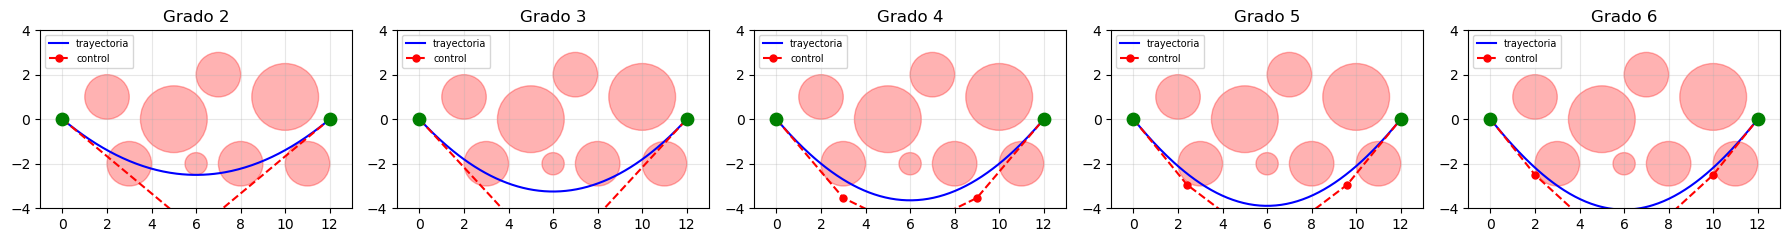

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb  

#11)a)
#  Creamos nuestra función que devuelva la matriz de funciones base de Bernstein de grado n 
# evaluadas en los valores de t recibidos
def bernstein_n(n, t):#t debe ser vector de los valores de t
    columnas = []
    for k in range(n + 1):
        coef = comb(n, k) #número combinatorio
        polinomio_k = coef * ((1 - t)**(n - k)) * (t**k)#python entiende que t es un vector/array, hace el produto en todo
        columnas.append(polinomio_k)
        
    return np.column_stack(columnas)#stack guarda como columnas los array de dentro de columnas

############################### separadores de incisos
#11)b)
def bezier(P, t):
    A = bernstein_n(P.shape[0]-1, t) 
    return A @ P#hace el produto AP -> te da una matriz con B(t)


###################################

#11)c)

# Estos son nuestros obstáculos
# [cx, cy, r]
obstaculos = np.array([
    [2,  1,   1.0],  
    [3, -2,   1.0],
    [5,  0,   1.5],
    [7,  2,   1.0],
    [8, -2,   1.0],
    [6, -2,   0.5],
    [10, 1,   1.5],
    [11,-2,   1.0],
])

# la función verificar_colisiones 
# recibe una curva de bezier evaluada en n puntos distintos y una matriz de los m obstáculos
# devuelve un vector de distancias minimas para cada obstaculo y un vector en donde cada indice dice True si colisiona o False sino
def verificar_colisiones(C: np.ndarray, obstaculos: np.ndarray):
    """ C          : array (n, 2) — puntos de la trayectoria ya evaluada "AP"
    obstaculos : array (m, 3) — cada fila es [cx, cy, r] """

    m = len(obstaculos)
    distancias_minimas = np.zeros(m) # crea un array de m ceros
    colisiones = np.zeros(m, dtype=bool)#todo 0

    for j in range(m):
        cj = obstaculos[j, :2]  # centro del obstáculo j, el [j, :2] significa agarrar los dos primeros elementos [cx, cy] coordenadas x e y del centro
        rj = obstaculos[j, 2]   # radio del obstáculo j

        # arrancamos con distancia minima infinita para ir actualizando
        dist_min_j = np.inf

        for i in range(len(C)): #para cada fila de la matriz C (la AP)
            # restamos el punto i de la curva con el centro del obstaculo j
            #aplicamos la fórmula de la consigna
            diferencia = C[i] - cj          # vector 2D
            dist = np.sqrt(diferencia[0]**2 + diferencia[1]**2)  # saco la norma a mano

            if dist < dist_min_j:
                dist_min_j = dist           # actualizamos el minimo


        distancias_minimas[j] = dist_min_j # me guardo ese minimo despues del ciclo, vector con j= el obstáculo
        colisiones[j] = dist_min_j < rj    # hay colision si la dist minima es menor al radio, True o False

    return distancias_minimas, colisiones

########
#11) d)
t: np.ndarray = np.linspace(0, 1, 200) #desde 0 a 1, dividido en 200


###########

#e)
grados = [2, 3, 4, 5, 6]

# Creo los puntos de control para los n tipos de grados con la perturbación vertical

def puntos_iniciales(n, a:float):
    # la funcion recibe el grado de la curva de bezier y nos devuelve la lista de n+1 puntos de control 
    # con la perturbación pedida en el inciso e
    P = np.zeros((n+1, 2))
    for k in range(n+1):
        P[k, 0] = 12 * k / n              # coordenada x
        P[k, 1] = a * np.sin(np.pi * k/n) # coordenada y, con la perturbación indicada
    return P


#############################
#f)
#inicio ploteo de los gráficos de 
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
print ("Elegimos un a = -5")
for ax, n in zip(axes, grados):
    P = puntos_iniciales(n, -5)
    C = bezier(P, t)
    
    # curva
    ax.plot(C[:, 0], C[:, 1], 'b-', label='trayectoria')#conecta con curva por el -
    
    # polígono de control
    ax.plot(P[:, 0], P[:, 1], 'ro--', markersize=5, label='control')#conecta con recta por el --
    
    # extremos O y D destacados
    ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80)
    
    # obstaculos
    for obs in obstaculos:#hace círulos para cada obs
        cx, cy, r = obs
        circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
        ax.add_patch(circulo)
    
    ax.set_title(f'Grado {n}')#f es para usar un valor en el medio del texto
    ax.set_xlim(-1, 13)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ejercicio 12: Optimización automática del grado y de la trayectoria


In [13]:
#12

# Recordar que P0 y Pn FIJOS y no variables, no entran en tita

#12 a)
def vector_a_matriz(theta):
    #Nos aseguramos de que theta sea un array de NumPy
    theta = np.asarray(theta)
    
    #"Desaplastamos" la tira plana en una matriz de puntos 2D.
    # Poner reshape(-1, 2) le dice a Python: "Agrupá todos estos números 
    # en 2 columnas (para X e Y), y el '-1' significa que vos calcules 
    # automáticamente cuántas filas se forman".
    P_intermedios = theta.reshape(-1, 2)
    
    #Definimos los extremos fijos que nos obliga la consigna
    P0 = np.array([[0.0, 0.0]])
    Pn = np.array([[12.0, 0.0]])
    
    #Apilamos todo verticalmente usando stack
    P_completa = np.vstack((P0, P_intermedios, Pn))
    
    return P_completa

### 12.B Término de Longitud ($E_{largo}$):
Cada evaluación $B_n(t_i)$ representa un punto específico sobre la curva de Bézier. Entre cada par de tiempos consecutivos ($t_i \rightarrow t_{i+1}$), se forma una "partecita" o pequeño segmento de la curva. Matemáticamente, la diferencia entre esos 2 puntos nos da un vector, y la norma de ese vector es exactamente la distancia entre ellos. En esta función se utiliza la norma al cuadrado como otra forma de medir esa distancia, lo cual evita problemas con valores negativos. Por lo tanto, si sumas las distancias de todos esos pares consecutivos a lo largo de la trayectoria, tenés una forma aproximada de calcular su largo total. Minimizar este término obliga al algoritmo a buscar el camino más corto posible.


$$E_{largo}(\theta) = \sum_{i=1}^{N-1} ||B_n(t_{i+1}) - B_n(t_i)||^2$$

Se minimiza: Cuando la trayectoria es una línea recta perfecta desde O a D. La suma de las distancias entre los 200 puntitos es la más corta posible.

Se maximiza: Si el robot hace una vuelta por los bordes del jardín antes de llegar al destino y trata de dar la mayor cantidad de vueltas o zig-zag posibles en los espacios sin obstáculos.




In [14]:
#12) b)

#Termino 1
def E_largo(curva_evaluada):
    """
    Calcula la suma de las distancias al cuadrado entre puntos consecutivos.
    """
    longitud = 0.0
    N = len(curva_evaluada) # Cantidad total de puntitos (200 en la consigna)
    
    # Recorremos desde el primer punto hasta el anteúltimo
    for i in range(N - 1):
        # Agarramos el par de puntos consecutivos
        punto_actual = curva_evaluada[i]
        punto_siguiente = curva_evaluada[i + 1]
        
        #calculamos la diferencia en X y en Y (el vector diferencia)
        dx = punto_siguiente[0] - punto_actual[0]
        dy = punto_siguiente[1] - punto_actual[1]
        
        #Calculamos la norma al cuadrado de este segmento (dx^2 + dy^2)
        distancia_cuadrada = (dx**2) + (dy**2)
        
        #Lo sumamos al total del recorrido
        longitud += distancia_cuadrada
        
    return longitud

### 12.B Término de Suavidad ($E_{suavidad}$): 

Primero, hay que aclarar que este término trabaja exclusivamente sobre las coordenadas de los puntos de control $P$, y no sobre los puntos evaluados de la curva de Bézier. Para entender qué se está calculando, hay que mirar a qué se le está aplicando la norma. Si tomamos la expresión interna $(P_{k-1} - 2P_k + P_{k+1})$, la reordenamos como $(P_{k-1} + P_{k+1}) - 2P_k$ y la pensamos dividida por 2, se obtienen dos elementos clave:

+ Un punto imaginario/medio (el promedio) ubicado exactamente entre el vecino anterior $P_{k-1}$ y el vecino siguiente $P_{k+1}$.

+ El punto central $P_k$.

Esas dos cosas se restan. Al hacer la norma cuadrada de esa resta, estamos obteniendo una medida directa de la distancia entre ese punto imaginario/promedio y nuestro punto real $P_k$. Mientras mayor sea esta distancia (es decir, mientras más alejado esté $P_k$ del centro de sus vecinos), más pronunciada y brusca será la curva generada en ese sector. Por lo tanto, la sumatoria de todas estas diferencias a lo largo del polígono es una excelente forma de medir qué tan brusco es el cambio entre los puntos $P$.

$$E_{suavidad}(\theta) = \sum_{k=1}^{n-1} ||P_{k-1} - 2P_k + P_{k+1}||^2$$


Se minimiza: El valor llega exactamente a 0 si tres puntos de control consecutivos ($P_{k-1}, P_k, P_{k+1}$) están perfectamente alineados en una recta y equidistantes. 

Se maximiza: Si los puntos de control forman ángulos muy agudos o "picos". Por ejemplo, si $P_1$ está muy arriba, $P_2$ muy abajo y $P_3$ muy arriba de nuevo. Esto obligaría al robot a dar giros violentos.

In [15]:
def E_suavidad(P):
    """
    Calcula la penalización por cambios bruscos en el polígono de control.
    Recibe la matriz P de todos los puntos de control.
    """
    suavidad = 0.0
    n = len(P) - 1 # El grado de la curva
    
    # Recorremos solo los puntos intermedios (desde k=1 hasta n-1)
    for k in range(1, n):
        #Identificamos al punto y a sus dos vecinos
        P_anterior = P[k-1]
        P_actual = P[k]
        P_siguiente = P[k+1]
        
        # Calculamos la resta interna de la fórmula para X y para Y
        dx =P_anterior[0] - 2 * P_actual[0] + P_siguiente[0]
        dy= P_anterior[1] - 2 * P_actual[1] + P_siguiente[1]
        
        #Calculamos la norma al cuadrado de esa diferencia
        distancia_cuadrada = (dx**2) + (dy**2)
        
        # Sumamos al total
        suavidad += distancia_cuadrada
        
    return suavidad

### 12.B Término de Obstáculos ($E_{obstaculos}$):

Las dos sumatorias de la fórmula actúan como un doble ciclo iterativo: por cada punto evaluado de la trayectoria ($B_n(t_i)$), se lo compara contra todos y cada uno de los obstáculos del jardín.Dentro de la función matemática $\max()$, la operación compara dos partes fundamentales: por un lado, el tamaño del obstáculo más el margen de seguridad ($r_j + \delta$); por el otro, la distancia real entre el punto de la curva y el centro del obstáculo. La función $\max$ actúa como un filtro con dos escenarios posibles:

+ Cuando hay colisión (o se invade el margen): El radio más el margen resulta ser mayor que la distancia real. Esto provoca que la resta interna dé un resultado positivo (+). Al comparar ese positivo contra 0, el $\max$ se queda con el valor de la resta.

+ Cuando NO hay colisión: El radio más el margen es menor que la distancia de la curva al centro. La resta da un resultado negativo (-). Al comparar un negativo contra 0, el $\max$ descarta la resta y se queda con el 0 (es decir, no hay penalización).

Finalmente, el número con el que se queda el $\max$ se eleva al cuadrado y se suma al acumulador total. Si la curva es segura, sumará puro ceros; si choca, acumulará valores positivos.

$$E_{obstaculos}(\theta) = \sum_{i=1}^{N}\sum_{j=1}^{M} [\max(0, r_j + \delta - ||B_n(t_i) - c_j||)]^2$$

Se minimiza: Su valor ideal es 0. Esto se logra (gracias a la función `max(0, ...)`) siempre y cuando el robot pase lo suficientemente lejos de todos los centros de los arbustos ($c_j$), respetando el radio ($r_j$) más el margen de seguridad ($\delta$).

Se maximiza: Toma valores positivos (castigo) si en alguno de los 200 instantes de tiempo el robot se "mete" en la zona prohibida del círculo. Mientras más se acerque al centro del arbusto (o peor, si lo atraviesa por el medio), más grande será el número elevado al cuadrado que suma a la penalización.

In [16]:
import math

def E_obstaculos(curva_evaluada, centros, radios, margen):
    """
    Calcula la penalización por acercarse o chocar contra los arbustos.
    - curva_evaluada: lista de los puntitos B_n(t_i) de la trayectoria.
    - centros: lista con las coordenadas [x, y] del centro de cada obstáculo.
    - radios: lista con el radio de cada obstáculo.
    - margen: el margen de seguridad delta.
    """
    Pen_obstaculos = 0.0
    
    # recorremos la curva de Bézier
    for punto in curva_evaluada:
        
        # comparamos cada puntito de la curva contra todos los obstáculos
        for j in range(len(centros)):
            centro_actual = centros[j]
            radio_actual = radios[j]
            
            # Calculamos la distancia del punto al centro del obstáculo
            dx = punto[0] - centro_actual[0]
            dy = punto[1] - centro_actual[1]
            distancia = math.sqrt((dx**2) + (dy**2))
            
            # Calculamos la resta que va adentro del max
            zona_prohibida = radio_actual + margen
            resta = zona_prohibida - distancia
            
            # Aplicamos la lógica del max: nos quedamos con la resta si es +, o con 0 si es -
            valor_penalizacion = max(0, resta)
            
            # Elevamos al cuadrado lo que nos quedó y lo sumamos al total
            Pen_obstaculos += (valor_penalizacion ** 2)
            
    return Pen_obstaculos

### 12.C Optimización de las trayectorias

In [17]:
import math

#TABLA DE OBSTÁCULOS
# Coordenadas [x, y] de los centros (Cj)
centros_obstaculos = np.array([
    [2, 1], [3, -2], [5, 0], [7, 2],
    [8, -2], [6, -2], [10, 1], [11, -2]
])
# Radios correspondientes a cada arbusto (rj)
radios_obstaculos = np.array([
    1.0, 1.0, 1.5, 1.0, 1.0, 0.5, 1.5, 1.0
])


# Generamos el array 't'(N=200)
t_eval = np.linspace(0, 1, 200)

In [18]:
#CONVERSIÓN A VECTOR THETA
def matriz_a_vector(P):
    """
    Recibe la matriz P, ignora los extremos O=(0,0) y D=(12,0), y extrae las coordenadas X e Y de los puntos intermedios para armar el vector theta paso a paso.
    """
    theta = []
    
    # Recorremos desde el segundo punto (índice 1) hasta el anteúltimo
    for i in range(1, len(P) - 1):
        punto_actual = P[i]
        
        # Agregamos primero la coordenada X y luego la Y a nuestra lista
        theta.append(punto_actual[0])
        theta.append(punto_actual[1])
        
    # Convertimos la lista final a un arreglo
    return np.array(theta)

In [19]:
#FUNCIÓN DE COSTO TOTAL DE E
def Costo_Total(theta):
    """
    Calcula el costo total sumando las 3 penalizaciones con sus respectivos pesos
    """
    # Parámetros fijados por la consigna 12.c
    lambda_suavidad = 0.1
    lambda_obs = 10.0
    
    margen_delta = 0.3
    
    
    #Reconstruimos la matriz P (usando la función del 12.a)
    P = vector_a_matriz(theta)
    
    # Evaluamos la curva de Bézier -> función del 11)
    curva_evaluada = bezier(P, t_eval)
    
    #  Calculamos los tres costos individuales
 
    e_largo = E_largo(curva_evaluada)
    e_suav = E_suavidad(P)
    e_obs = E_obstaculos(curva_evaluada, centros_obstaculos, radios_obstaculos, margen_delta)
    
    #  Sumamos todo aplicando la fórmula de la consigna
    costo_final = e_largo + (lambda_suavidad * e_suav) + (lambda_obs * e_obs)
    
    return costo_final

In [20]:
#CÁLCULO DEL GRADIENTE
def calcular_gradiente(theta, epsilon=1e-5):
    """
    Calcula el gradiente usando diferencias finitas 
    """
    gradiente = np.zeros(len(theta))
    #llena de 0 todo el espacio que necesitamos para guardar luego el gradiente
    
    # Recorremos cada variable dentro de theta
    for k in range(len(theta)):
        # Armamos el vector canónico e_k
        e_k = np.zeros(len(theta))
        e_k[k] = 1.0
        
        # Calculamos los dos movimientos: hacia adelante y hacia atrás
        theta_mas = theta + (epsilon * e_k)
        theta_menos = theta - (epsilon * e_k)
        
        # Evaluamos el costo en esos dos nuevos puntos
        costo_mas = Costo_Total(theta_mas)
        costo_menos = Costo_Total(theta_menos)
        
        # Aplicamos la fórmula central de la consigna
        derivada_k = (costo_mas - costo_menos) / (2 * epsilon)
        
        # Guardamos el resultado
        gradiente[k] = derivada_k
        
    return gradiente

In [21]:
def gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300):
    """
    Recibe un tita inicial y lo optimiza
    """
    #  hacemos una copia para no alterar el original
    theta = theta_inicial.copy()
    
    # Creamos una lista para guardar la historia
    historial = []
    
    #Hacemos el ciclo usando el seguro de iteraciones máximas
    for i in range(max_iteraciones):
        
        # Evaluamos cómo está el costo en este momento
        costo_actual = Costo_Total(theta)
        
        # Guardamos la iteración y el costo en nuestra lista
        historial.append([i, costo_actual])
        
        # Frena antes si E(tita) es 0 (usamos un valor casi 0 por los decimales de la PC)
        if costo_actual < 1e-5:
            print(f"Freno anticipado en la iteración {i}. Se llegó al minimo")
            break
            
        # Usamos las funciones antes codeadas para calcular el gradiente
        gradiente = calcular_gradiente(theta)
        
        # Actualizamos tita restando el gradiente multiplicado por el paso (alpha)
        theta = theta - (alpha * gradiente)
        
    
    #Convertimos la lista en una matriz de NumPy para poder graficarla fácil en el 12.d
    matriz_historial = np.array(historial)
        
    return theta, matriz_historial

### 12.D Y 12. E Ahora, para cada n ∈ {2,3,4,5,6}

Al correr cada celda, se cumplirá el 12) d) y e) 

Optimización finalizada para n=2
Matriz P optimizada:
 [[ 0.          0.        ]
 [-2.36986476 -2.77771832]
 [12.          0.        ]]

--- Análisis de Criterios (Grado 2) ---
E_obstaculos (Penalización por choques/margen): 14.0242
Error Total (E): 172.6044


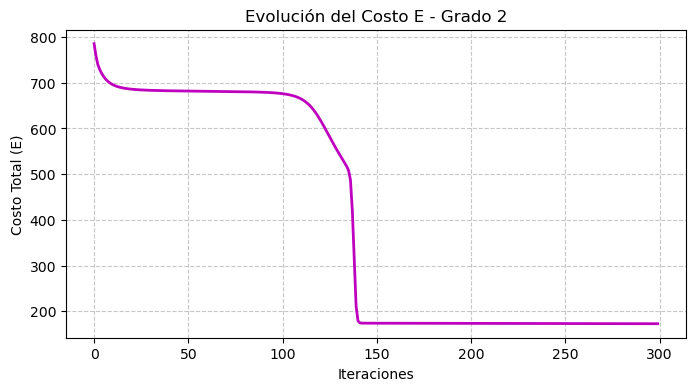

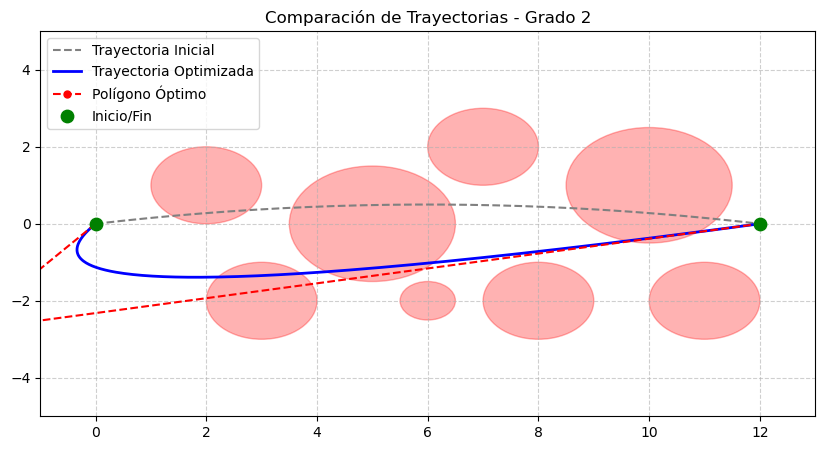

In [22]:
# Seteamos n 
n = 2

#Llamar a la función  (n, a=1)-> tenemos P
P_inicial = puntos_iniciales(n, a=1)

#Meter P en la función que nos da Tita
theta_inicial = matriz_a_vector(P_inicial)

# Metemos Tita en la función de gradiente descendiente y guardamos la matriz
theta_optimo, historial_E = gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300)

# (Opcional para ver el resultado) Imprimimos el Tita final o reconstruimos P
P_final_optimizada_2 = vector_a_matriz(theta_optimo)
print(f"Optimización finalizada para n={n}")
print("Matriz P optimizada:\n", P_final_optimizada_2)




# ==========================================
# VERIFICACIÓN DE CRITERIOS PARA f) y g)
# ==========================================
# 1. Reconstruimos la curva final para evaluarla
curva_final_2 = bezier(P_final_optimizada_2, t_eval)

# 2. Calculamos solo el E_obstaculos
costo_obs = E_obstaculos(curva_final_2, centros_obstaculos, radios_obstaculos, margen=0.3)

# 3. Rescatamos el error total final desde el historial
costo_total_2 = historial_E[-1][1]

print(f"\n--- Análisis de Criterios (Grado {n}) ---")
print(f"E_obstaculos (Penalización por choques/margen): {costo_obs:.4f}")
print(f"Error Total (E): {costo_total_2:.4f}")




#grafiocos de 12 d) y e) con IA
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICO DE LA CURVA DE COSTO 
# ==========================================
plt.figure(figsize=(8, 4))

# historial_E[:, 0] son las iteraciones (eje X)
# historial_E[:, 1] son los valores de la función de costo E (eje Y)
plt.plot(historial_E[:, 0], historial_E[:, 1], 'm-', linewidth=2)

plt.title(f"Evolución del Costo E - Grado {n}")
plt.xlabel("Iteraciones")
plt.ylabel("Costo Total (E)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 2. GRÁFICO DE LA TRAYECTORIA EN EL JARDÍN
# ==========================================
# Evaluamos AMBAS curvas usando la función bezier
C_inicial = bezier(P_inicial, t_eval)          # <--- Agregamos la inicial
C_final = bezier(P_final_optimizada_2, t_eval)

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Dibujamos la trayectoria INICIAL (en gris y punteada para comparar)
ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1.5, label='Trayectoria Inicial')
# (Opcional) Si querés ver los puntos P iniciales, descomentá la línea de abajo:
# ax.plot(P_inicial[:, 0], P_inicial[:, 1], color='gray', marker='s', linestyle=':', markersize=4, label='Polígono Inicial')

# 2. Dibujamos la trayectoria OPTIMIZADA (en azul fuerte)
ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Trayectoria Optimizada')
ax.plot(P_final_optimizada_2[:, 0], P_final_optimizada_2[:, 1], 'ro--', markersize=5, label='Polígono Óptimo')

# 3. Marcamos el Origen y el Destino
ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80, label='Inicio/Fin')

# 4. Dibujamos los arbustos 
for i in range(len(centros_obstaculos)):
    cx, cy = centros_obstaculos[i]
    r = radios_obstaculos[i]
    circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
    ax.add_patch(circulo)

ax.set_title(f'Comparación de Trayectorias - Grado {n}')
ax.set_xlim(-1, 13)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

Optimización finalizada para n=3
Matriz P optimizada:
 [[ 0.          0.        ]
 [ 3.18772788  7.24736237]
 [ 8.1379067  -3.42584696]
 [12.          0.        ]]

--- Análisis de Criterios (Grado 3) ---
E_obstaculos (Penalización por choques/margen): 0.9601
Error Total (E): 63.0630


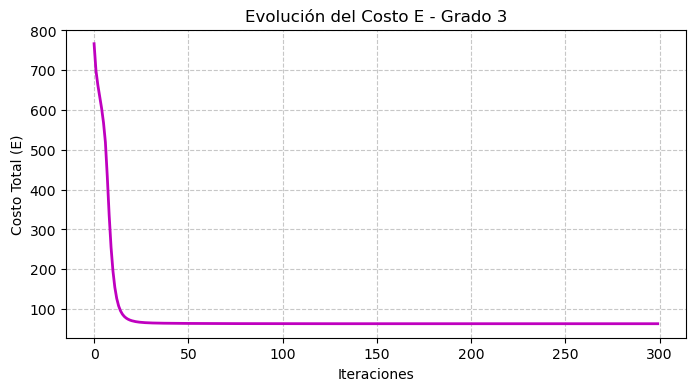

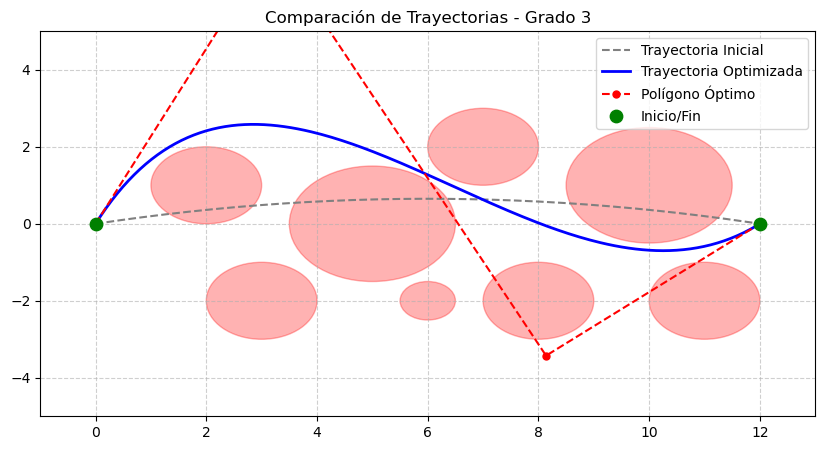

In [23]:
# Seteamos n 
n = 3

#Llamar a la función  (n, a=1)-> tenemos P
P_inicial = puntos_iniciales(n, a=1)

#Meter P en la función que nos da Tita
theta_inicial = matriz_a_vector(P_inicial)

# Metemos Tita en la función de gradiente descendiente y guardamos la matriz
theta_optimo, historial_E = gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300)

# (Opcional para ver el resultado) Imprimimos el Tita final o reconstruimos P
P_final_optimizada_3 = vector_a_matriz(theta_optimo)
print(f"Optimización finalizada para n={n}")
print("Matriz P optimizada:\n", P_final_optimizada_3)



# ==========================================
# VERIFICACIÓN DE CRITERIOS PARA f) y g)
# ==========================================
# 1. Reconstruimos la curva final para evaluarla
curva_final_3 = bezier(P_final_optimizada_3, t_eval)

# 2. Calculamos solo el E_obstaculos
costo_obs = E_obstaculos(curva_final_3, centros_obstaculos, radios_obstaculos, margen=0.3)

# 3. Rescatamos el error total final desde el historial
costo_total_3 = historial_E[-1][1]

print(f"\n--- Análisis de Criterios (Grado {n}) ---")
print(f"E_obstaculos (Penalización por choques/margen): {costo_obs:.4f}")
print(f"Error Total (E): {costo_total_3:.4f}")



#grafiocos de 12 d) y e) con IA
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICO DE LA CURVA DE COSTO 
# ==========================================
plt.figure(figsize=(8, 4))

# historial_E[:, 0] son las iteraciones (eje X)
# historial_E[:, 1] son los valores de la función de costo E (eje Y)
plt.plot(historial_E[:, 0], historial_E[:, 1], 'm-', linewidth=2)

plt.title(f"Evolución del Costo E - Grado {n}")
plt.xlabel("Iteraciones")
plt.ylabel("Costo Total (E)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 2. GRÁFICO DE LA TRAYECTORIA EN EL JARDÍN
# ==========================================
# Evaluamos AMBAS curvas usando la función bezier
C_inicial = bezier(P_inicial, t_eval)          # <--- Agregamos la inicial
C_final = bezier(P_final_optimizada_3, t_eval)

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Dibujamos la trayectoria INICIAL (en gris y punteada para comparar)
ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1.5, label='Trayectoria Inicial')
# (Opcional) Si querés ver los puntos P iniciales, descomentá la línea de abajo:
# ax.plot(P_inicial[:, 0], P_inicial[:, 1], color='gray', marker='s', linestyle=':', markersize=4, label='Polígono Inicial')

# 2. Dibujamos la trayectoria OPTIMIZADA (en azul fuerte)
ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Trayectoria Optimizada')
ax.plot(P_final_optimizada_3[:, 0], P_final_optimizada_3[:, 1], 'ro--', markersize=5, label='Polígono Óptimo')

# 3. Marcamos el Origen y el Destino
ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80, label='Inicio/Fin')

# 4. Dibujamos los arbustos 
for i in range(len(centros_obstaculos)):
    cx, cy = centros_obstaculos[i]
    r = radios_obstaculos[i]
    circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
    ax.add_patch(circulo)

ax.set_title(f'Comparación de Trayectorias - Grado {n}')
ax.set_xlim(-1, 13)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

Optimización finalizada para n=4
Matriz P optimizada:
 [[ 0.          0.        ]
 [ 8.18861489  1.79410491]
 [ 4.2255729   4.72477332]
 [ 6.38903763 -3.12501442]
 [12.          0.        ]]

--- Análisis de Criterios (Grado 4) ---
E_obstaculos (Penalización por choques/margen): 8.4217
Error Total (E): 128.8627


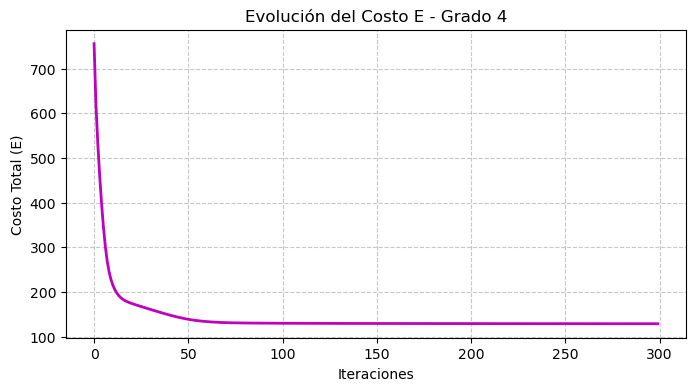

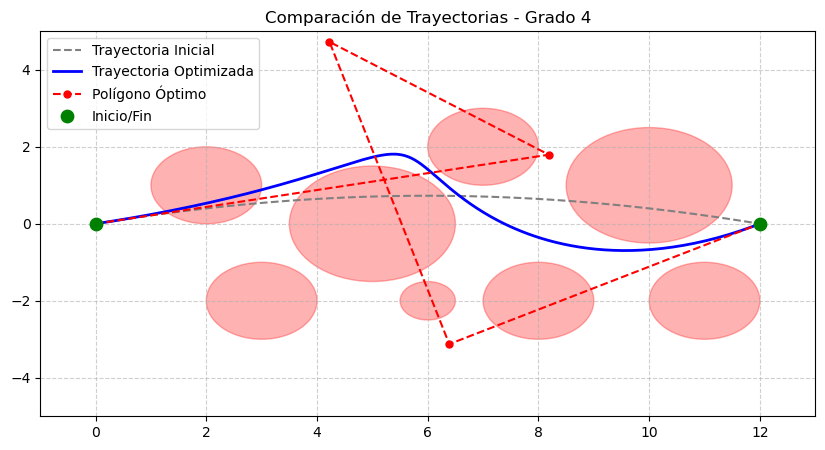

In [24]:
# Seteamos n 
n = 4

#Llamar a la función  (n, a=1)-> tenemos P
P_inicial = puntos_iniciales(n, a=1)

#Meter P en la función que nos da Tita
theta_inicial = matriz_a_vector(P_inicial)

# Metemos Tita en la función de gradiente descendiente y guardamos la matriz
theta_optimo, historial_E = gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300)

# (Opcional para ver el resultado) Imprimimos el Tita final o reconstruimos P
P_final_optimizada_4 = vector_a_matriz(theta_optimo)
print(f"Optimización finalizada para n={n}")
print("Matriz P optimizada:\n", P_final_optimizada_4)



# ==========================================
# VERIFICACIÓN DE CRITERIOS PARA f) y g)
# ==========================================
# 1. Reconstruimos la curva final para evaluarla
curva_final_4 = bezier(P_final_optimizada_4, t_eval)

# 2. Calculamos solo el E_obstaculos
costo_obs = E_obstaculos(curva_final_4, centros_obstaculos, radios_obstaculos, margen=0.3)

# 3. Rescatamos el error total final desde el historial
costo_total_4 = historial_E[-1][1]

print(f"\n--- Análisis de Criterios (Grado {n}) ---")
print(f"E_obstaculos (Penalización por choques/margen): {costo_obs:.4f}")
print(f"Error Total (E): {costo_total_4:.4f}")




#grafiocos de 12 d) y e) con IA
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICO DE LA CURVA DE COSTO 
# ==========================================
plt.figure(figsize=(8, 4))

# historial_E[:, 0] son las iteraciones (eje X)
# historial_E[:, 1] son los valores de la función de costo E (eje Y)
plt.plot(historial_E[:, 0], historial_E[:, 1], 'm-', linewidth=2)

plt.title(f"Evolución del Costo E - Grado {n}")
plt.xlabel("Iteraciones")
plt.ylabel("Costo Total (E)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 2. GRÁFICO DE LA TRAYECTORIA EN EL JARDÍN
# ==========================================
# Evaluamos AMBAS curvas usando la función bezier
C_inicial = bezier(P_inicial, t_eval)          # <--- Agregamos la inicial
C_final = bezier(P_final_optimizada_4, t_eval)

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Dibujamos la trayectoria INICIAL (en gris y punteada para comparar)
ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1.5, label='Trayectoria Inicial')
# (Opcional) Si querés ver los puntos P iniciales, descomentá la línea de abajo:
# ax.plot(P_inicial[:, 0], P_inicial[:, 1], color='gray', marker='s', linestyle=':', markersize=4, label='Polígono Inicial')

# 2. Dibujamos la trayectoria OPTIMIZADA (en azul fuerte)
ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Trayectoria Optimizada')
ax.plot(P_final_optimizada_4[:, 0], P_final_optimizada_4[:, 1], 'ro--', markersize=5, label='Polígono Óptimo')

# 3. Marcamos el Origen y el Destino
ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80, label='Inicio/Fin')

# 4. Dibujamos los arbustos 
for i in range(len(centros_obstaculos)):
    cx, cy = centros_obstaculos[i]
    r = radios_obstaculos[i]
    circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
    ax.add_patch(circulo)

ax.set_title(f'Comparación de Trayectorias - Grado {n}')
ax.set_xlim(-1, 13)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

Optimización finalizada para n=5
Matriz P optimizada:
 [[ 0.          0.        ]
 [ 4.47228541 -2.17455012]
 [ 3.98020938  4.71131651]
 [ 4.637256    3.97901782]
 [ 7.6808897  -3.14467595]
 [12.          0.        ]]

--- Análisis de Criterios (Grado 5) ---
E_obstaculos (Penalización por choques/margen): 0.8914
Error Total (E): 41.9572


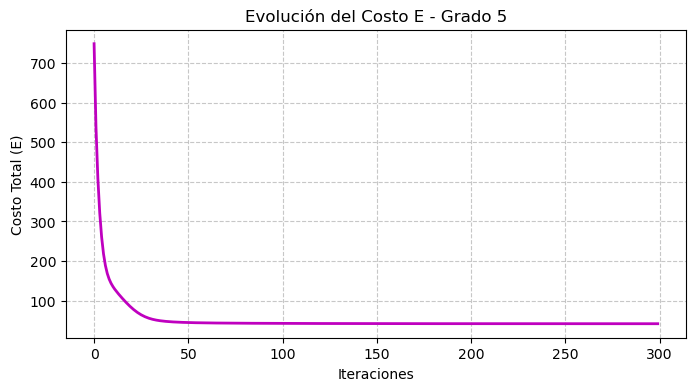

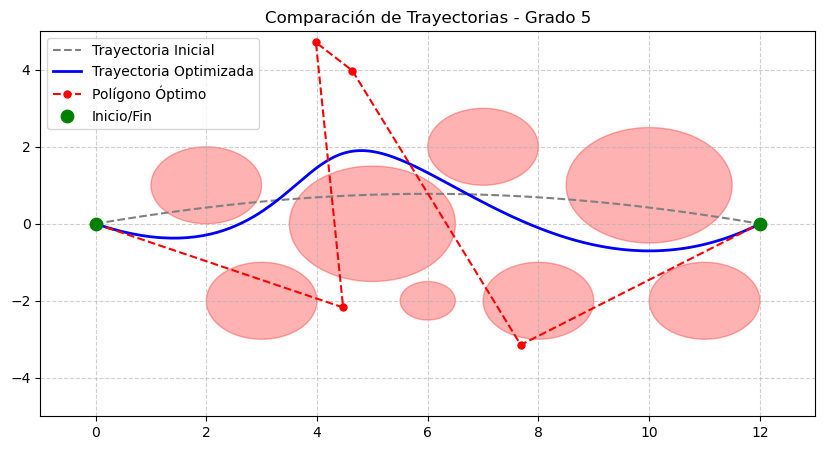

In [25]:
# Seteamos n 
n = 5

#Llamar a la función  (n, a=1)-> tenemos P
P_inicial = puntos_iniciales(n, a=1)

#Meter P en la función que nos da Tita
theta_inicial = matriz_a_vector(P_inicial)

# Metemos Tita en la función de gradiente descendiente y guardamos la matriz
theta_optimo, historial_E = gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300)

# (Opcional para ver el resultado) Imprimimos el Tita final o reconstruimos P
P_final_optimizada_5 = vector_a_matriz(theta_optimo)
print(f"Optimización finalizada para n={n}")
print("Matriz P optimizada:\n", P_final_optimizada_5)

# ==========================================
# VERIFICACIÓN DE CRITERIOS PARA f) y g)
# ==========================================
# 1. Reconstruimos la curva final para evaluarla
curva_final_5 = bezier(P_final_optimizada_5, t_eval)

# 2. Calculamos solo el E_obstaculos
costo_obs = E_obstaculos(curva_final_5, centros_obstaculos, radios_obstaculos, margen=0.3)

# 3. Rescatamos el error total final desde el historial
costo_total_5 = historial_E[-1][1]

print(f"\n--- Análisis de Criterios (Grado {n}) ---")
print(f"E_obstaculos (Penalización por choques/margen): {costo_obs:.4f}")
print(f"Error Total (E): {costo_total_5:.4f}")





#grafiocos de 12 d) y e) con IA
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICO DE LA CURVA DE COSTO 
# ==========================================
plt.figure(figsize=(8, 4))

# historial_E[:, 0] son las iteraciones (eje X)
# historial_E[:, 1] son los valores de la función de costo E (eje Y)
plt.plot(historial_E[:, 0], historial_E[:, 1], 'm-', linewidth=2)

plt.title(f"Evolución del Costo E - Grado {n}")
plt.xlabel("Iteraciones")
plt.ylabel("Costo Total (E)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 2. GRÁFICO DE LA TRAYECTORIA EN EL JARDÍN
# ==========================================
# Evaluamos AMBAS curvas usando la función bezier
C_inicial = bezier(P_inicial, t_eval)          # <--- Agregamos la inicial
C_final = bezier(P_final_optimizada_5, t_eval)

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Dibujamos la trayectoria INICIAL (en gris y punteada para comparar)
ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1.5, label='Trayectoria Inicial')
# (Opcional) Si querés ver los puntos P iniciales, descomentá la línea de abajo:
# ax.plot(P_inicial[:, 0], P_inicial[:, 1], color='gray', marker='s', linestyle=':', markersize=4, label='Polígono Inicial')

# 2. Dibujamos la trayectoria OPTIMIZADA (en azul fuerte)
ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Trayectoria Optimizada')
ax.plot(P_final_optimizada_5[:, 0], P_final_optimizada_5[:, 1], 'ro--', markersize=5, label='Polígono Óptimo')

# 3. Marcamos el Origen y el Destino
ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80, label='Inicio/Fin')

# 4. Dibujamos los arbustos 
for i in range(len(centros_obstaculos)):
    cx, cy = centros_obstaculos[i]
    r = radios_obstaculos[i]
    circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
    ax.add_patch(circulo)

ax.set_title(f'Comparación de Trayectorias - Grado {n}')
ax.set_xlim(-1, 13)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

Optimización finalizada para n=6
Matriz P optimizada:
 [[ 0.          0.        ]
 [ 3.914707   -2.02018432]
 [ 4.05437666  2.50469759]
 [ 4.09517445  4.93454326]
 [ 5.71735819  1.22310187]
 [ 8.516227   -2.68486426]
 [12.          0.        ]]

--- Análisis de Criterios (Grado 6) ---
E_obstaculos (Penalización por choques/margen): 0.5295
Error Total (E): 21.1103


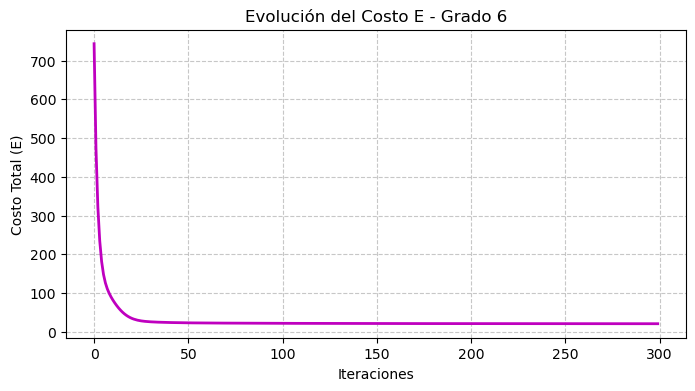

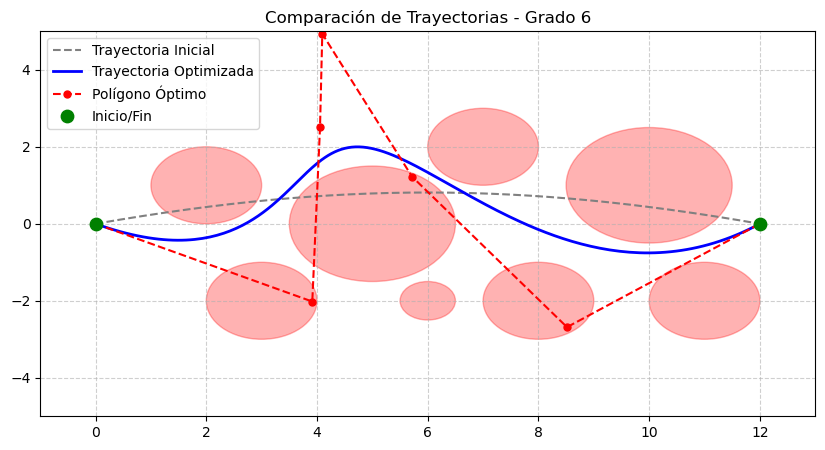

In [26]:
# Seteamos n 
n = 6

#Llamar a la función  (n, a=1)-> tenemos P
P_inicial = puntos_iniciales(n, a=1)

#Meter P en la función que nos da Tita
theta_inicial = matriz_a_vector(P_inicial)

# Metemos Tita en la función de gradiente descendiente y guardamos la matriz
theta_optimo, historial_E = gradiente_descendiente(theta_inicial, alpha=0.005, max_iteraciones=300)

# (Opcional para ver el resultado) Imprimimos el Tita final o reconstruimos P
P_final_optimizada_6 = vector_a_matriz(theta_optimo)
print(f"Optimización finalizada para n={n}")
print("Matriz P optimizada:\n", P_final_optimizada_6)

# ==========================================
# VERIFICACIÓN DE CRITERIOS PARA f) y g)
# ==========================================
# 1. Reconstruimos la curva final para evaluarla
curva_final_6 = bezier(P_final_optimizada_6, t_eval)

# 2. Calculamos solo el E_obstaculos
costo_obs = E_obstaculos(curva_final_6, centros_obstaculos, radios_obstaculos, margen=0.3)

# 3. Rescatamos el error total final desde el historial
costo_total_6 = historial_E[-1][1]

print(f"\n--- Análisis de Criterios (Grado {n}) ---")
print(f"E_obstaculos (Penalización por choques/margen): {costo_obs:.4f}")
print(f"Error Total (E): {costo_total_6:.4f}")


#grafiocos de 12 d) y e) con IA
import matplotlib.pyplot as plt

# ==========================================
# 1. GRÁFICO DE LA CURVA DE COSTO 
# ==========================================
plt.figure(figsize=(8, 4))

# historial_E[:, 0] son las iteraciones (eje X)
# historial_E[:, 1] son los valores de la función de costo E (eje Y)
plt.plot(historial_E[:, 0], historial_E[:, 1], 'm-', linewidth=2)

plt.title(f"Evolución del Costo E - Grado {n}")
plt.xlabel("Iteraciones")
plt.ylabel("Costo Total (E)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ==========================================
# 2. GRÁFICO DE LA TRAYECTORIA EN EL JARDÍN
# ==========================================
# Evaluamos AMBAS curvas usando la función bezier
C_inicial = bezier(P_inicial, t_eval)          # <--- Agregamos la inicial
C_final = bezier(P_final_optimizada_6, t_eval)

fig, ax = plt.subplots(figsize=(10, 5))

# 1. Dibujamos la trayectoria INICIAL (en gris y punteada para comparar)
ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1.5, label='Trayectoria Inicial')
# (Opcional) Si querés ver los puntos P iniciales, descomentá la línea de abajo:
# ax.plot(P_inicial[:, 0], P_inicial[:, 1], color='gray', marker='s', linestyle=':', markersize=4, label='Polígono Inicial')

# 2. Dibujamos la trayectoria OPTIMIZADA (en azul fuerte)
ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Trayectoria Optimizada')
ax.plot(P_final_optimizada_6[:, 0], P_final_optimizada_6[:, 1], 'ro--', markersize=5, label='Polígono Óptimo')

# 3. Marcamos el Origen y el Destino
ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=80, label='Inicio/Fin')

# 4. Dibujamos los arbustos 
for i in range(len(centros_obstaculos)):
    cx, cy = centros_obstaculos[i]
    r = radios_obstaculos[i]
    circulo = plt.Circle((cx, cy), r, color='red', alpha=0.3)
    ax.add_patch(circulo)

ax.set_title(f'Comparación de Trayectorias - Grado {n}')
ax.set_xlim(-1, 13)
ax.set_ylim(-5, 5)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

### 12.F Criterio de Factibilidad: Flexibilidad Operativa

Para determinar si una trayectoria optimizada es **factible** (válida y útil para la podadora), utilizaremos un criterio realista que busca un equilibrio entre seguridad y eficiencia. Exigir un respeto absoluto y milimétrico del margen de seguridad $\delta$ muchas veces obliga al algoritmo a generar maniobras erráticas o rodeos inmensos que arruinan la lógica del recorrido. Por lo tanto, nuestras condiciones de factibilidad son:

1. **Tolerancia en el Margen de Seguridad ($E_{obstaculos} < 1$):** Es preferible "rozar" levemente la zona de advertencia del arbusto (sin llegar a chocarlo físicamente) antes que obligar a la podadora a dar vueltas ineficientes por el jardín. Aceptamos una penalización mínima en este término, asumiendo el riesgo controlado.
2. **Eficiencia del recorrido ($E_{total} \le 50$):** La trayectoria global debe mantenerse dentro de un límite de costo total razonable, evitando caminos excesivamente largos o con curvas bruscas e innecesarias.

### 12.G Evaluación de Factibilidad y Elección del Grado Óptimo

Aplicando nuestro criterio de flexibilidad operativa, analizamos los valores finales de las trayectorias optimizadas para cada grado $n$:

* **Grado 2:** $E_{obs} = [14.02]$, $E_{total} = [172.6044]$ $\rightarrow$ [No Factible]
* **Grado 3:** $E_{obs} = [0.96]$, $E_{total} = [63.06]$ $\rightarrow$ [No Factible]
* **Grado 4:** $E_{obs} = [8.42]$, $E_{total} = [128.86]$ $\rightarrow$ [No Factible]
* **Grado 5:** $E_{obs} = [0.89]$, $E_{total} = [41.95]$ $\rightarrow$ [Factible]
* **Grado 6:** $E_{obs} = [0.52]$, $E_{total} = [21.11]$ $\rightarrow$ [Factible]

**Conclusión:**
Bajo este enfoque práctico, observamos que exigir un error de obstáculos exactamente igual a cero descartaba curvas que visualmente eran muy buenas. Al flexibilizar el margen ($E_{obs} < 1$), evitamos penalizar en exceso trayectorias que son altamente eficientes en distancia y suavidad. 

Por lo tanto, el grado elegido como la trayectoria óptima definitiva es **$n = [5]$**, ya que representa el grado más bajo que logra cruzar el jardín eficientemente, asumiendo un roce aceptable en los márgenes pero garantizando que no hay colisiones reales.

# Ejercicio 13: Análisis de la trayectoria obtenida


In [27]:
import math

def largo_aprox(curva_evaluada):
    """
    Calcula la suma de las distancia entre puntos consecutivos
    Usamos la función de costo pero con un sqrt()!!!!!!!!!!!!!!!!!!!!!!!!!!! es la misma que hicimos antes
    
    recibe un AP -> debe devolver un numero con a long aprox
    """
    longitud = 0.0
    N = len(curva_evaluada) # Cantidad total de puntitos (200 en la consigna)
    
    # Recorremos desde el primer punto hasta el anteúltimo
    for i in range(N - 1):
        # Agarramos el par de puntos consecutivos
        punto_actual = curva_evaluada[i]
        punto_siguiente = curva_evaluada[i + 1]
        
        #calculamos la diferencia en X y en Y (el vector diferencia)
        dx = punto_siguiente[0] - punto_actual[0]
        dy = punto_siguiente[1] - punto_actual[1]
        
        #Calculamos la norma de este segmento (dx^2 + dy^2)
        distancia = math.sqrt((dx**2) + (dy**2))
        
        #Lo sumamos al total del recorrido
        longitud += distancia
        
    return longitud

In [28]:
def analizar_resultados(matrices_P, grados, t_eval, centros_obstaculos, radios_obstaculos):
    """
    Recibe una lista con las 5 matrices de puntos de control optimizadas (una por grado)
    y arma una tabla comparando, para cada una: longitud aproximada, cantidad de
    colisiones, distancia mínima a un obstáculo y costo final.
    
    matrices_P: lista de 5 matrices P (puntos de control completos, incluyendo P0 y Pn)
    grados: lista con el grado n correspondiente a cada matriz (ej: [2,3,4,5,6])
    t_eval: vector de t usado para evaluar las curvas (np.linspace(0,1,200))
    centros_obstaculos, radios_obstaculos: arrays con la info de los obstáculos
    """
    
    # verificar_colisiones espera la matriz de obstaculos como (m,3) = [cx, cy, r]
    obstaculos = np.column_stack((centros_obstaculos, radios_obstaculos))#es la matriz que guarda la info de los obstaculos
    
    resultados = []  # acá guardamos una fila por cada grado
    
    for P, n in zip(matrices_P, grados):
        # Evaluamos la curva de Bézier a partir de los puntos de control P
        C = bezier(P, t_eval)
        
        # 1)Longitud aproximada de la trayectoria
        longitud = largo_aprox(C)
        
        # 2) Distancias mínimas a cada obstáculo + si hubo colisión
        distancias_minimas, colisiones = verificar_colisiones(C, obstaculos)
        
        cantidad_colisiones = np.sum(colisiones)       # cuántos obstáculos fueron tocados
        distancia_min_global = np.min(distancias_minimas)   # la distancia más chica de todas
        
        # 3)    Costo final: convertimos P a theta y evaluamos Costo_Total######
        theta = matriz_a_vector(P)
        costo = Costo_Total(theta)
        
        resultados.append((n, longitud, cantidad_colisiones, distancia_min_global, costo))#se guarda de cada resultado todo eso
    
    #    Armamos e imprimimos la tabla 
    print(f"{'Grado':>6} | {'Longitud':>10} | {'Colisiones':>11} | {'Dist. mín':>10} | {'Costo final':>12}")
    print("-" * 62)
    for n, longitud, colis, dist_min, costo in resultados:
        print(f"{n:>6} | {longitud:>10.4f} | {colis:>11} | {dist_min:>10.4f} | {costo:>12.4f}")#son variables, las printea a todas segun lo guardado en resultado
    
    return resultados

matrices_P = [P_final_optimizada_2, P_final_optimizada_3, P_final_optimizada_4,
              P_final_optimizada_5, P_final_optimizada_6]
grados = [2, 3, 4, 5, 6]

#llamamos a la función creada
tabla_resultados = analizar_resultados(matrices_P, grados, t_eval, centros_obstaculos, radios_obstaculos)




 Grado |   Longitud |  Colisiones |  Dist. mín |  Costo final
--------------------------------------------------------------
     2 |    13.5027 |           3 |     0.6536 |     172.5953
     3 |    14.2131 |           0 |     1.1549 |      63.0630
     4 |    13.3270 |           1 |     0.4478 |     128.8603
     5 |    13.7931 |           0 |     1.1433 |      41.9569
     6 |    14.0376 |           0 |     1.1446 |      21.1088


## 13.B - ¿Qué pasa conforme aumenta el grado?

Vimos que cuanto mas aumenta el grado, la trayectoria optima encontrada se flexibiliza mas, tiene mas curvatura independientemente de que sea factible o no. 

Más variables libres significa que el optimizador tiene más margen para deformar la curva y esquivar obstáculos. Esa es la razón de fondo por la que grados bajos pueden quedar atrapados sin solución factible, mientras que grados altos casi siempre logran zafar. 

Al aumentar el grado, la curva dispone de más grados de libertad para flexibilizarse, pero cuánta curvatura efectivamente toma depende del balance entre esa libertad y el término de suavidad λ_suavidad. Por eso, más allá del grado mínimo necesario para ser factible, agregar más grado no necesariamente agrega curvatura útil, puede agregar puntos de control "redundantes" que se acomodan de forma casi colineal, sin curvar mucho, simplemente porque el costo de longitud y suavidad ya está bien resuelto.

## 13.C y D - Versión parametrizada de Costo_Total

Es la misma función de antes, pero ahora lambda_suavidad y lambda_obs son parámetros en vez de estar fijos adentro de la función.

Así podemos llamarla con distintos valores sin tener que copiarla.

In [29]:
# Versión parametrizada de Costo_Total
# Es la misma función de antes, pero ahora lambda_suavidad y lambda_obs
# son PARÁMETROS en vez de estar fijos adentro de la función.
# Así podemos llamarla con distintos valores sin tener que copiarla.

def costo_total_param(theta, lambda_suavidad, lambda_obs, margen_delta=0.3):
    """
    Igual que Costo_Total, pero permite elegir lambda_suavidad y lambda_obs
    en cada llamado (en vez de tenerlos fijos, que fue como la hicimos en el 12)
    """
    P = vector_a_matriz(theta)
    curva_evaluada = bezier(P, t_eval)

    e_largo = E_largo(curva_evaluada)
    e_suav  = E_suavidad(P)
    e_obs   = E_obstaculos(curva_evaluada, centros_obstaculos, radios_obstaculos, margen_delta)

    costo_final = e_largo + (lambda_suavidad * e_suav) + (lambda_obs * e_obs)
    return costo_final

In [30]:
# Gradiente y descenso parametrizados
# Mismas funciones que ya teníamos, pero ahora reciben lambda_suavidad y lambda_obs y se los "pasan" a costo_total_param.

def calcular_gradiente_param(theta, lambda_suavidad, lambda_obs, epsilon=1e-5):
    gradiente = np.zeros(len(theta))
    for k in range(len(theta)):
        e_k = np.zeros(len(theta))
        e_k[k] = 1.0
        costo_mas  = costo_total_param(theta + epsilon*e_k, lambda_suavidad, lambda_obs)
        costo_menos = costo_total_param(theta - epsilon*e_k, lambda_suavidad, lambda_obs)
        gradiente[k] = (costo_mas - costo_menos) / (2 * epsilon)
    return gradiente


def gradiente_descendiente_param(theta_inicial, lambda_suavidad, lambda_obs,
                                  alpha=0.005, max_iteraciones=300):
    theta = theta_inicial.copy()
    historial = []
    for i in range(max_iteraciones):
        costo_actual = costo_total_param(theta, lambda_suavidad, lambda_obs)
        historial.append([i, costo_actual])
        if costo_actual < 1e-5:
            break
        grad = calcular_gradiente_param(theta, lambda_suavidad, lambda_obs)
        theta = theta - (alpha * grad)
    return theta, np.array(historial)

In [31]:
# experimento_lambda es una función que corre un experimento completo para una combinación de lambdas
# Hace lo mismo que lo que hicimos  "a mano" en cada celda del ejercicio 12,
#pero ahora para los lambdas por parámerot, y devuelve todo lo necesario para después armar la tabla

def experimento_lambda(n, lambda_suavidad, lambda_obs, a=1):
    """
    n: grado de la curva a usar (el elegido como factible en el ej. 12)
    lambda_suavidad, lambda_obs: los pesos a probar
    a: amplitud de la perturbación inicial (misma que usaron en el ej. 11/12)
    
    Devuelve: P_final, historial_E, C_inicial, C_final
    """
    # Punto de partida (igual que en el ejercicio 12)
    P_inicial = puntos_iniciales(n, a)
    theta_inicial = matriz_a_vector(P_inicial)

    # Optimización con los lambdas elegidos
    theta_final, historial_E = gradiente_descendiente_param(
        theta_inicial, lambda_suavidad, lambda_obs
    )
    P_final = vector_a_matriz(theta_final)

    # Curvas para graficar (inicial vs. optimizada)
    C_inicial = bezier(P_inicial, t_eval)
    C_final   = bezier(P_final, t_eval)

    return P_final, historial_E, C_inicial, C_final

In [32]:
# Graficado reusable 
# Recibe un "ax" (un subplot) en vez de crear su propia figura,
# así podemos meter varias combinaciones de lambda en una sola figura por grado

def graficar_trayectoria(ax, C_inicial, C_final, P_final, titulo):
    ax.plot(C_inicial[:, 0], C_inicial[:, 1], color='gray', linestyle='--', linewidth=1, label='Inicial')
    ax.plot(C_final[:, 0], C_final[:, 1], 'b-', linewidth=2, label='Optimizada')
    ax.plot(P_final[:, 0], P_final[:, 1], 'ro--', markersize=3, label='Control')
    ax.scatter([0, 12], [0, 0], color='green', zorder=5, s=50)

    for i in range(len(centros_obstaculos)):
        cx, cy = centros_obstaculos[i]
        r = radios_obstaculos[i]
        ax.add_patch(plt.Circle((cx, cy), r, color='red', alpha=0.3))

    ax.set_title(titulo, fontsize=9)
    ax.set_xlim(-1, 13)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')
    ax.grid(True, linestyle='--', alpha=0.5)

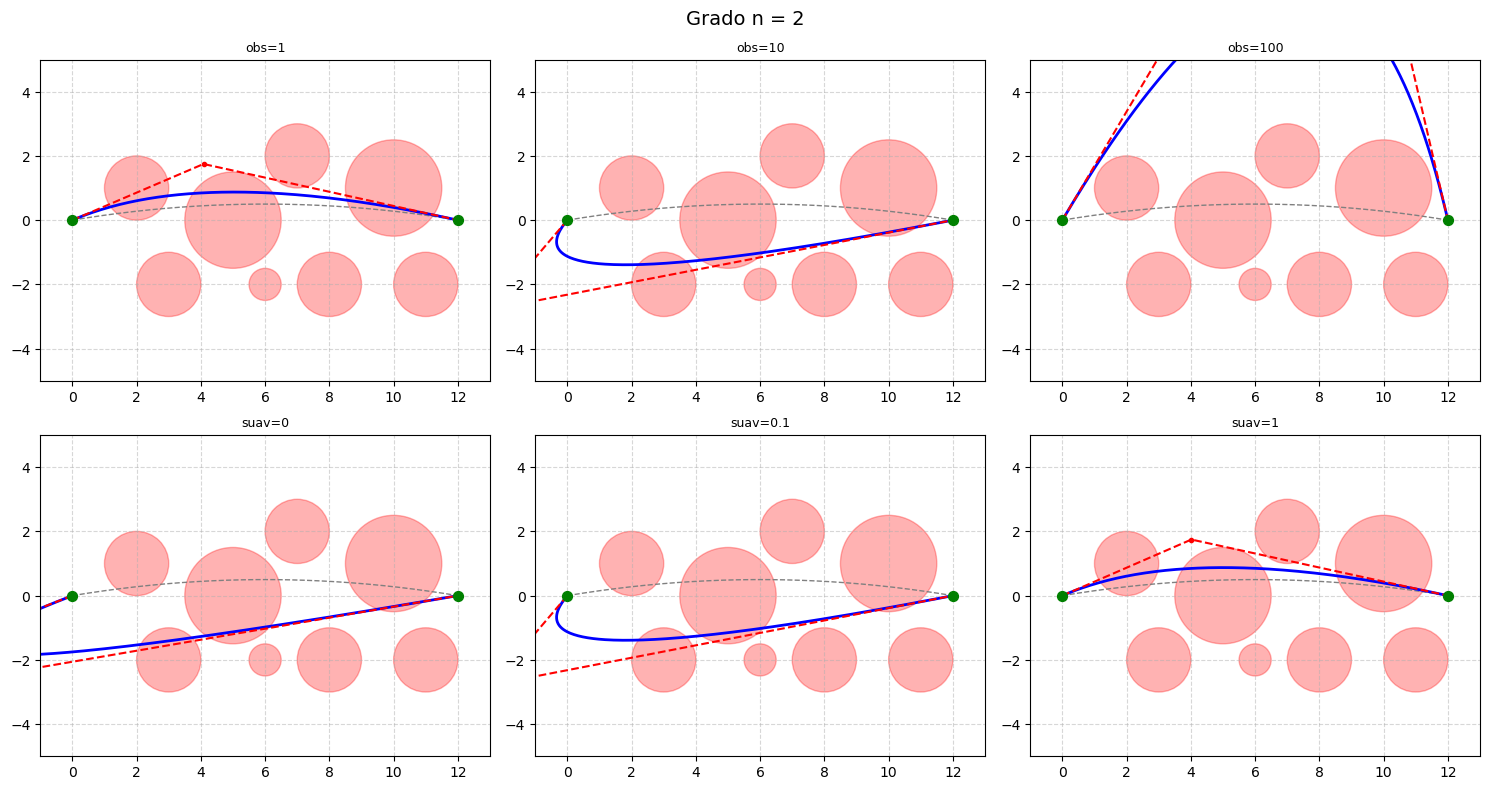

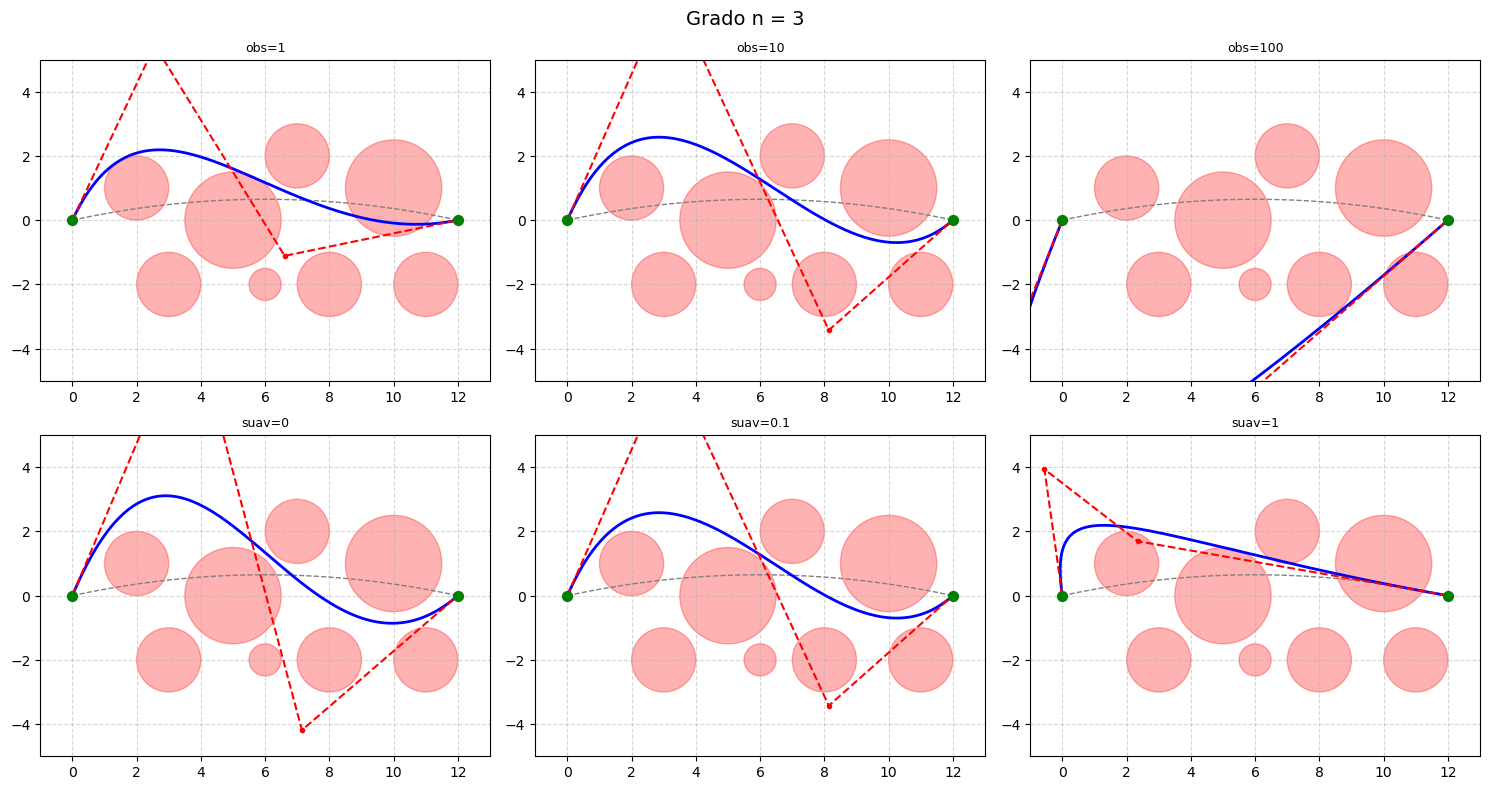

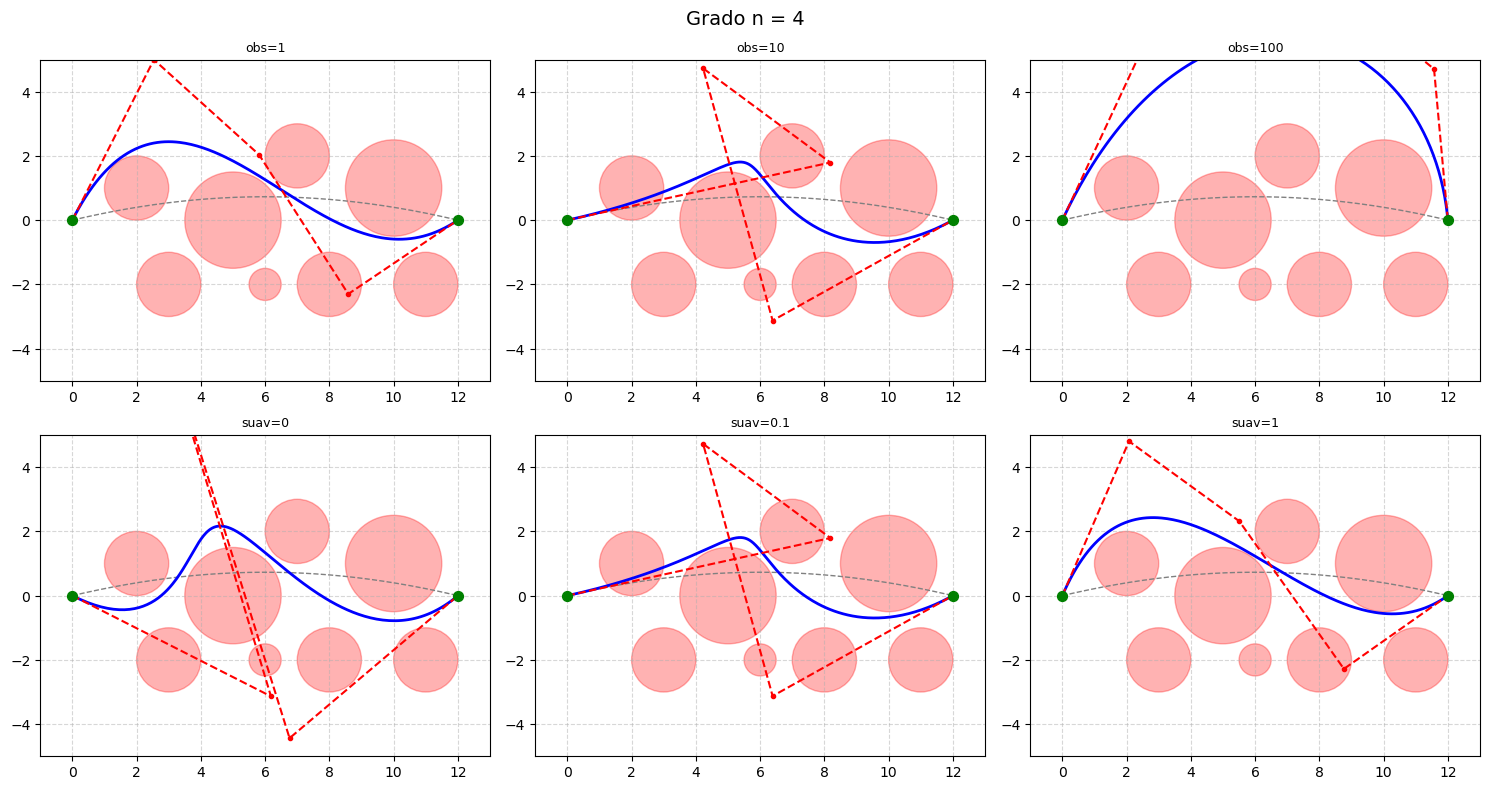

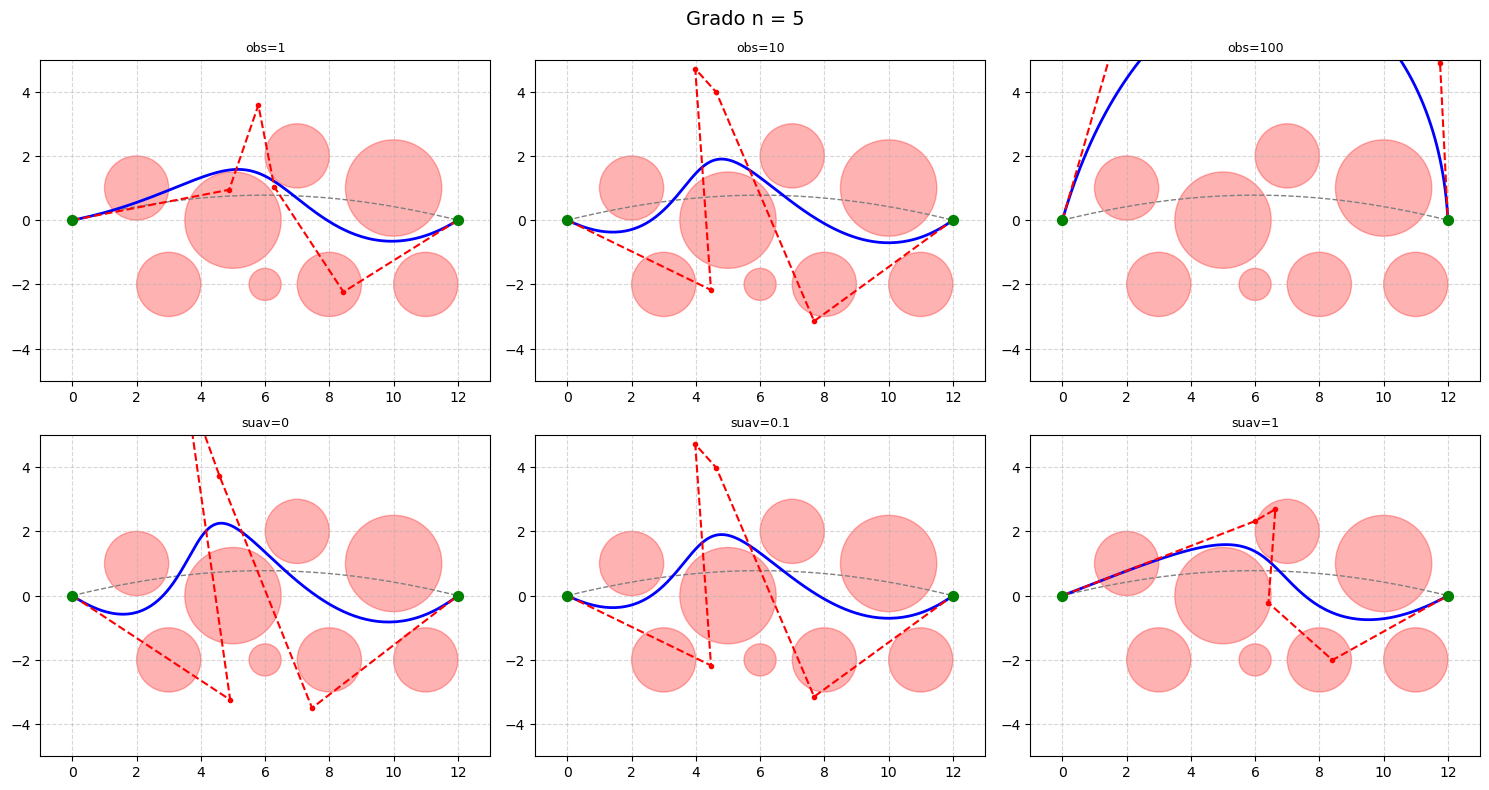

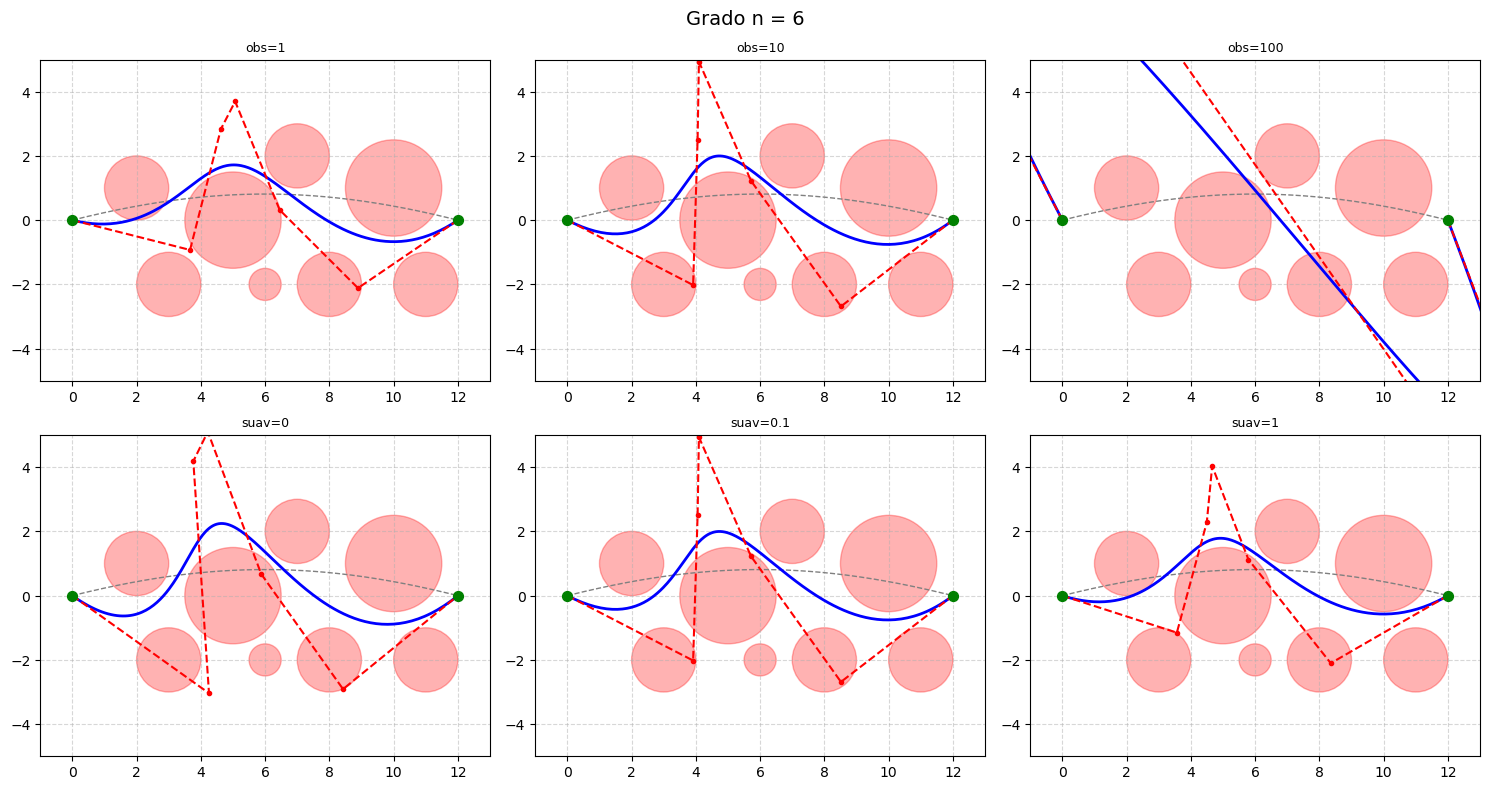

In [33]:
# Ciclo principal: probamos las 6 combinaciones de lambda PARA CADA GRADO
grados_a_probar = [2, 3, 4, 5, 6]

# Lambda "de referencia" (los valores originales de la consigna del ejercicio 12)
LAMBDA_SUAV_BASE = 0.1
LAMBDA_OBS_BASE  = 10.0

# Combinaciones a probar:
# - punto c): variamos lambda_obs, dejando lambda_suavidad fijo en el valor base
# - punto d): variamos lambda_suavidad, dejando lambda_obs fijo en el valor base
combinaciones = [
    ("obs=1",    LAMBDA_SUAV_BASE, 1),
    ("obs=10",   LAMBDA_SUAV_BASE, 10),
    ("obs=100",  LAMBDA_SUAV_BASE, 100),
    ("suav=0",   0,   LAMBDA_OBS_BASE),
    ("suav=0.1", 0.1, LAMBDA_OBS_BASE),
    ("suav=1",   1,   LAMBDA_OBS_BASE),
]

obstaculos = np.column_stack((centros_obstaculos, radios_obstaculos))  # para verificar_colisiones

resultados_lambda = []  # acá guardamos UNA fila por cada (grado, combinación)

# Recorremos cada grado
for n in grados_a_probar:

    # Una figura por grado, con 6 subplots (uno por combinación) en 2 filas x 3 columnas
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"Grado n = {n}", fontsize=14)
    axes = axes.flatten()  # para poder recorrerlas con un solo índice

    # Recorremos cada combinación de lambda para este grado
    for idx, (etiqueta, lam_suav, lam_obs) in enumerate(combinaciones):

        # Corremos el experimento completo: optimiza y devuelve curvas/puntos
        P_final, historial_E, C_inicial, C_final = experimento_lambda(n, lam_suav, lam_obs)

        # Graficamos SOLO la trayectoria en el subplot correspondiente
        graficar_trayectoria(axes[idx], C_inicial, C_final, P_final,
                              titulo=f"{etiqueta}")

        # Calculamos las métricas para la tabla (mismas que en el ej. 13.a)
        longitud = largo_aprox(C_final)
        distancias_minimas, colisiones = verificar_colisiones(C_final, obstaculos)
        cantidad_colisiones = np.sum(colisiones)
        distancia_min_global = np.min(distancias_minimas)
        theta_final = matriz_a_vector(P_final)
        costo_final = costo_total_param(theta_final, lam_suav, lam_obs)

        # Guardamos la fila: grado + combinación + métricas
        resultados_lambda.append((n, etiqueta, longitud, cantidad_colisiones,
                                   distancia_min_global, costo_final))

    plt.tight_layout()
    plt.show()

In [34]:
# Tabla final: una fila por cada (grado, combinación de lambda)

print(f"{'Grado':>6} | {'Combinación':>12} | {'Longitud':>10} | {'Colisiones':>11} | {'Dist. mín':>10} | {'Costo final':>12}")
print("-" * 75)

grado_anterior = None
for n, etiqueta, longitud, colis, dist_min, costo in resultados_lambda:
    # Separador visual cada vez que cambiamos de grado, para que se lea más fácil
    if grado_anterior is not None and n != grado_anterior:
        print("-" * 75)
    print(f"{n:>6} | {etiqueta:>12} | {longitud:>10.4f} | {colis:>11} | {dist_min:>10.4f} | {costo:>12.4f}")
    grado_anterior = n

 Grado |  Combinación |   Longitud |  Colisiones |  Dist. mín |  Costo final
---------------------------------------------------------------------------
     2 |        obs=1 |    12.1777 |           3 |     0.3899 |      72.2522
     2 |       obs=10 |    13.5027 |           3 |     0.6536 |     172.5953
     2 |      obs=100 |    19.8727 |           0 |     1.1760 |     101.5719
     2 |       suav=0 |    18.5679 |           3 |     0.5896 |      97.8251
     2 |     suav=0.1 |    13.5027 |           3 |     0.6536 |     172.5953
     2 |       suav=1 |    12.1783 |           3 |     0.3854 |     715.5547
---------------------------------------------------------------------------
     3 |        obs=1 |    13.3900 |           2 |     1.0037 |      35.5226
     3 |       obs=10 |    14.2131 |           0 |     1.1549 |      63.0630
     3 |      obs=100 |    25.0430 |           1 |     0.8715 |     139.8348
     3 |       suav=0 |    15.0139 |           0 |     1.1510 |       4.5741
 

## 13.E Nuestra elección de una trayectoria para la podadora robot

In [35]:
# Verificación numérica: ¿el grado 3 es realmente el mejor?
# Usamos los resultados ya calculados en tabla_resultados (celda del 13.a)
# tabla_resultados es una lista de tuplas: (n, longitud, colisiones, dist_min, costo)

print("Resumen de factibilidad y longitud por grado:")
print(f"{'Grado':>6} | {'Colisiones':>11} | {'Factible?':>10} | {'Longitud':>10} | {'Dist. mín':>10}")#solo títulos
print("-" * 58)

grados_factibles = []  # acá guardamos los grados que NO colisionan

for n, longitud, colis, dist_min, costo in tabla_resultados:
    
    factible = colis == 0#True si no hay colision
    if factible:#solo las guarda si no hay colison
        grados_factibles.append((n, longitud))
    print(f"{n:>6} | {colis:>11} | {str(factible):>10} | {longitud:>10.4f} | {dist_min:>10.4f}")#estas variables estaban creadas en el 13)a
    #printea todos los valores de esas variables del 13)a)
print()

# Identificamos el menor grado factible (criterio de la consigna del ej. 12.g)
if grados_factibles:
    grado_minimo_factible = grados_factibles[0][0]#variable creada en esta celda que tiene los factibles
    print(f"Menor grado factible: n = {grado_minimo_factible}")
    
    # Comparamos su longitud contra TODOS los grados factibles (no solo contra el mínimo)
    print("\nComparación de longitudes entre grados factibles:")
    for n, longitud in grados_factibles:
        print(f"  Grado {n}: longitud = {longitud:.4f}")
    
    longitudes_factibles = [l for _, l in grados_factibles]
    grado_mas_corto = grados_factibles[longitudes_factibles.index(min(longitudes_factibles))][0]
    print(f"\nEl grado con la trayectoria MÁS CORTA entre los factibles es: n = {grado_mas_corto}")
else:
    print("Ningún grado resultó factible con estos parámetros.")

Resumen de factibilidad y longitud por grado:
 Grado |  Colisiones |  Factible? |   Longitud |  Dist. mín
----------------------------------------------------------
     2 |           3 |      False |    13.5027 |     0.6536
     3 |           0 |       True |    14.2131 |     1.1549
     4 |           1 |      False |    13.3270 |     0.4478
     5 |           0 |       True |    13.7931 |     1.1433
     6 |           0 |       True |    14.0376 |     1.1446

Menor grado factible: n = 3

Comparación de longitudes entre grados factibles:
  Grado 3: longitud = 14.2131
  Grado 5: longitud = 13.7931
  Grado 6: longitud = 14.0376

El grado con la trayectoria MÁS CORTA entre los factibles es: n = 5


Elegimos la trayectoria de n=3 calculada en el ejercicio 12b cuando estuvimos optimizando por estas tres razones:

1. **La diferencia de longitud es chica**: Si bien no es la de menor longitud entre las factibles, la de grado 3 es solo un ~3% más larga que grado 5 (14.21 vs 13.79). No es una diferencia que cambie radicalmente el tiempo de poda o el gasto de batería de la podadora.
2. **Tiene la mejor distancia mínima a los obstáculos de las tres**: Eso es directamente un argumento de seguridad porque aunque no sea la más corta, es la que pasa más lejos de los arbustos en su punto más cercano. Para una podadora real, creemos que ese margen extra importa más que ahorrarse un 3% de longitud.
3. **Es la más simple**: 2 puntos de control intermedios contra 4 de grado 5. Menos parámetros significa una curva más fácil de describir, de mantener, con menos riesgo de zigzags raros y de no ser tan suave.

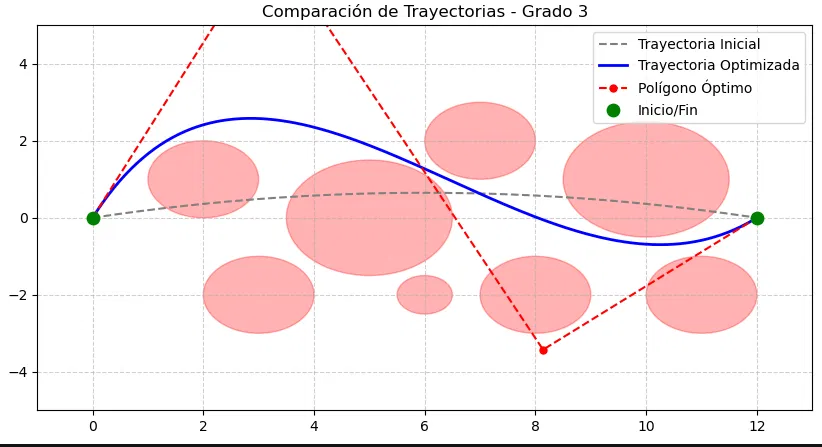

## 13.F

En este problema aparecen varias ideas centrales de la materia trabajando en conjunto.


 La función de costo total se construye sumando términos que tienen la forma de normas al cuadrado de diferencias, la misma estructura algebraica que vimos en el ajuste por mínimos cuadrados de los primeros ejercicios, solo que ahora aplicada a la longitud de la trayectoria y a la suavidad del polígono de control en lugar de al error entre una curva y datos observados.


También notamos que cada uno de estos términos es una forma cuadrática en las variables del problema, ya que se expresan como sumas de cuadrados de combinaciones lineales de los puntos de control. 
En otras palabras, elevar al cuadrado una expresión lineal siempre termina generando productos cruzados entre las variables, $\theta_i \theta_j$, que es justamente la definición de una forma cuadrática.


 El término de suavidad cumple además el rol de una regularización, porque penaliza soluciones con curvatura brusca aunque estas minimicen mejor la longitud o evadan mejor los obstáculos, evitando así trayectorias poco realistas para un robot físico.
 

  Como la función de costo combina estos términos con el de evitar obstáculos, que no es estrictamente cuadrático por el uso del máximo, ya no podemos resolver el problema de forma cerrada como en mínimos cuadrados clásicos, y necesitamos optimización numérica: usamos diferencias finitas para aproximar el gradiente y gradiente descendiente para ir actualizando los puntos de control de forma iterativa hasta encontrar una trayectoria que minimice el costo total.